<a href="https://colab.research.google.com/github/imenk-cloud/my-novel/blob/main/RLS_VLM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## STEP 0 - setup

In [ ]:
import os, subprocess, shlex, shutil, sys, torch
REPO = "/content/rls-tiny-vlm"
if not os.path.exists(REPO):
    subprocess.run(["git", "clone", "https://github.com/RLS-ResearchLab/RLS-Entrance-Challenge.git", REPO], check=True)
os.chdir(REPO)
for d in ["src/model", "tests", "configs", "scripts", "benchmarks/S1_throughput", "experiments/E0_overfit",
          "experiments/E1_blind", "experiments/E3_visual_mask", "results", "report", "data"]:
    os.makedirs(d, exist_ok=True)
open("src/__init__.py", "a").close(); open("src/model/__init__.py", "a").close()

def run(cmd):
    # run a shell command and stream its output live into the notebook
    print("$", cmd)
    p = subprocess.Popen(cmd, shell=True, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True, bufsize=1)
    for line in p.stdout:
        print(line, end="")
    p.wait()
    if p.returncode != 0:
        raise RuntimeError(f"command failed (exit {p.returncode}): {cmd}")

def commit(msg):
    subprocess.run("git add -A && git commit -q -m " + shlex.quote(msg), shell=True)

print("torch", torch.__version__, "| cuda:", torch.cuda.is_available())
if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))
print(os.getcwd())

torch 2.11.0+cu130 | cuda: True
Tesla T4
/content/rls-tiny-vlm


### (optional but recommended) Google Drive backup - Colab deletes files when the session ends

In [ ]:
from google.colab import drive
drive.mount("/content/drive")
DRIVE_DIR = "/content/drive/MyDrive/rls-tiny-vlm-backup"

def backup():
    shutil.copytree(REPO, DRIVE_DIR, dirs_exist_ok=True, ignore=shutil.ignore_patterns("data", "__pycache__"))
    print("backed up to", DRIVE_DIR)

def restore():   # use after a Colab restart: copies the backup back into the repo folder
    shutil.copytree(DRIVE_DIR, REPO, dirs_exist_ok=True)
    print("restored from", DRIVE_DIR)

Mounted at /content/drive


### Git: your own repository
1. Create an **empty** repo on GitHub (e.g. `rls-tiny-vlm`).
2. Fill in the 3 values below. For the token: GitHub > Settings > Developer settings > Personal access tokens (scope `repo`).

In [ ]:
import getpass
GIT_NAME  = "imen khedimallah"
GIT_EMAIL = "ikehedimallah@gmail.com"
GITHUB_USER_REPO = "imenk-cloud/rls-tiny-vlm"      # <user>/<repo>
run(f'git config user.name "{GIT_NAME}"'); run(f'git config user.email "{GIT_EMAIL}"')
with open(".gitignore", "a") as f:
    f.write("\ndata/\n*.pt\n__pycache__/\n.pytest_cache/\n")

def push():
    token = getpass.getpass("GitHub token (hidden): ")
    url = f"https://{token}@github.com/{GITHUB_USER_REPO}.git"
    subprocess.run(["git", "remote", "remove", "origin"], capture_output=True)
    subprocess.run(["git", "remote", "add", "origin", url], check=True)
    r = subprocess.run("git branch -M main && git push -u origin main", shell=True, capture_output=True, text=True)
    print((r.stdout + r.stderr).replace(token, "***"))

$ git config user.name "YOUR NAME"
$ git config user.email "you@example.com"


## STEP 1 - generate the data with the OFFICIAL generator (fixed seed 42, do not edit it)

In [ ]:
run("python generate_data.py --out-dir data")
run("ls -lh data && sha256sum data/*.pt > results/data_sha256.txt && cat results/data_sha256.txt")

$ python generate_data.py --out-dir data

train: 100%|██████████| 20000/20000 [00:11<00:00, 1750.88it/s]
train: 20000 samples in 12.0s -> data/train.pt

val: 100%|██████████| 2000/2000 [00:01<00:00, 1792.96it/s]
val: 2000 samples in 1.2s -> data/val.pt

test: 100%|██████████| 2000/2000 [00:01<00:00, 1985.13it/s]
test: 2000 samples in 1.1s -> data/test.pt

test_heldout: 100%|██████████| 2000/2000 [00:00<00:00, 2226.78it/s]
test_heldout: 2000 samples in 1.0s -> data/test_heldout.pt
meta -> data/meta.json
$ ls -lh data && sha256sum data/*.pt > results/data_sha256.txt && cat results/data_sha256.txt
total 306M
-rw-r--r-- 1 root root  864 Oct  2 01:24 meta.json
-rw-r--r-- 1 root root  24M Oct  2 01:24 test_heldout.pt
-rw-r--r-- 1 root root  24M Oct  2 01:24 test.pt
-rw-r--r-- 1 root root 236M Oct  2 01:24 train.pt
-rw-r--r-- 1 root root  24M Oct  2 01:24 val.pt
9f1b582708e657a8c671898d8c73fe47abbfff9480d9a8f82257f0f5eeb69a88  data/test.pt
79c17a44028f96eb6a6634501c46a0b2eb79b53dc5d127ac73510

## STEP 2 - write the source files (one cell per file; read them!)

In [ ]:
%%writefile src/tokenizer.py
# Character-level tokenizer: 26 letters (ids 0-25) + <eos> (id 26) = 27 tokens.
# DESIGN CHOICES (the brief does not fix them): <eos> = 26, padding id = 0, ignored in the loss via -100.
import string

import torch

LETTERS = string.ascii_lowercase
EOS_ID = 26
PAD_ID = 0            # any valid id works for padding because padded targets are ignored
IGNORE_INDEX = -100   # value used in labels so CrossEntropyLoss skips padded positions
VOCAB_SIZE = 27


class CharTokenizer:
    def __init__(self):
        self.stoi = {c: i for i, c in enumerate(LETTERS)}
        self.itos = {i: c for c, i in self.stoi.items()}
        self.eos_id = EOS_ID
        self.vocab_size = VOCAB_SIZE

    def encode(self, word):
        # "red" -> [17, 4, 3, 26]   (letters then <eos>, length len(word)+1)
        return [self.stoi[c] for c in word] + [self.eos_id]

    def decode(self, ids):
        # stops at the first <eos>; ids may be a list or a 1-D tensor
        out = []
        for i in ids:
            i = int(i)
            if i == self.eos_id:
                break
            out.append(self.itos.get(i, ""))
        return "".join(out)

    def encode_batch(self, words):
        return pad_sequences([torch.tensor(self.encode(w), dtype=torch.long) for w in words])


def pad_sequences(seqs):
    # seqs: list of 1-D LongTensors of different lengths
    # returns ids (B, T_max) padded with PAD_ID, and lengths (B,)
    lengths = torch.tensor([len(s) for s in seqs], dtype=torch.long)
    ids = torch.full((len(seqs), int(lengths.max())), PAD_ID, dtype=torch.long)
    for b, s in enumerate(seqs):
        ids[b, : len(s)] = s
    return ids, lengths


def make_labels(ids, lengths):
    # ids (B, T), lengths (B,) -> labels (B, T) with IGNORE_INDEX on padded positions
    T = ids.size(1)
    is_pad = torch.arange(T, device=ids.device)[None, :] >= lengths[:, None]
    return ids.masked_fill(is_pad, IGNORE_INDEX)


TOKENIZER = CharTokenizer()

Overwriting src/tokenizer.py


In [ ]:
%%writefile src/parsing.py
# Robust parser: turns a (possibly misspelled) generated word back into attributes.
# No torch dependency on purpose, so it can be unit-tested anywhere.
# DESIGN CHOICE: the brief only asks for a parser that survives broken outputs; this is a fuzzy
# matcher based on edit distance and on the known grammar  size+color+shape [+relation+size+color+shape].

SIZES = ["small", "large"]
COLORS = ["red", "green", "blue", "yellow"]
SHAPES = ["circle", "square", "triangle", "cross"]
RELATIONS = ["leftof", "rightof", "above", "below"]
HELD_OUT_PAIRS = [("green", "triangle"), ("yellow", "cross"), ("blue", "square")]
SLOTS = ["size1", "color1", "shape1", "relation", "size2", "color2", "shape2"]


def edit_distance(a, b):
    # classic Levenshtein distance (insert / delete / substitute, cost 1 each)
    prev = list(range(len(b) + 1))
    for i, ca in enumerate(a, 1):
        cur = [i]
        for j, cb in enumerate(b, 1):
            cur.append(min(prev[j] + 1, cur[j - 1] + 1, prev[j - 1] + (ca != cb)))
        prev = cur
    return prev[-1]


def best_prefix_match(s, candidates):
    # which candidate does the start of s look most like? returns (candidate, number of chars consumed)
    best = None
    for c in candidates:
        for k in range(max(1, len(c) - 1), len(c) + 2):
            key = (edit_distance(s[:k], c), abs(k - len(c)))
            if best is None or key < best[0]:
                best = (key, c, k)
    return best[1], best[2]


def parse_object(s):
    size, k = best_prefix_match(s, SIZES)
    s = s[k:]
    color, k = best_prefix_match(s, COLORS)
    s = s[k:]
    shape, _ = best_prefix_match(s, SHAPES)
    return size, color, shape


def find_relation(w):
    # look for the relation word (allowing up to 2 edits) with at least 10 letters on each side
    best = None
    for rel in RELATIONS:
        for k in range(len(rel) - 1, len(rel) + 2):
            for st in range(10, len(w) - k - 10 + 1):
                d = edit_distance(w[st : st + k], rel)
                if d <= 2:
                    key = (d, abs(k - len(rel)))
                    if best is None or key < best[0]:
                        best = (key, rel, st, st + k)
    return None if best is None else best[1:]


def parse_word(w):
    out = {s: None for s in SLOTS}
    if not w:
        return out
    found = find_relation(w)
    if found is None:
        out["size1"], out["color1"], out["shape1"] = parse_object(w)
    else:
        rel, st, en = found
        out["size1"], out["color1"], out["shape1"] = parse_object(w[:st])
        out["relation"] = rel
        out["size2"], out["color2"], out["shape2"] = parse_object(w[en:])
    return out


def rebuild_word(p):
    w = p["size1"] + p["color1"] + p["shape1"]
    if p["relation"] is not None:
        w += p["relation"] + p["size2"] + p["color2"] + p["shape2"]
    return w

Writing src/parsing.py


In [ ]:
%%writefile src/data.py
# Dataset + collate + preprocessing for ShapeScenes (files produced by generate_data.py).
from pathlib import Path

import torch
from torch.utils.data import Dataset

from src.tokenizer import TOKENIZER, pad_sequences


class ShapeScenes(Dataset):
    # each item: image uint8 (3, 64, 64), ids LongTensor (len(word)+1,)  [letters + <eos>]
    def __init__(self, split, data_dir="data", max_items=None):
        blob = torch.load(Path(data_dir) / f"{split}.pt", weights_only=False)  # our own file, safe
        images, words = blob["images"], blob["words"]
        if max_items:
            images, words = images[:max_items], words[:max_items]
        self.images = images                      # (N, 3, 64, 64) uint8, kept in RAM
        self.words = words                        # list[str]
        self.ids = [torch.tensor(TOKENIZER.encode(w), dtype=torch.long) for w in words]

    def __len__(self):
        return len(self.words)

    def __getitem__(self, i):
        return self.images[i], self.ids[i]


def collate(batch):
    images = torch.stack([b[0] for b in batch])          # (B, 3, 64, 64) uint8
    ids, lengths = pad_sequences([b[1] for b in batch])  # (B, T_max), (B,)
    return {"images": images, "ids": ids, "lengths": lengths}


def preprocess(images_u8, blind="none"):
    # uint8 (B,3,64,64) -> float in [-1, 1]. Done on the device, after the transfer.
    # blind="zeros": the model sees all-zero images (E1). blind="shuffle": images are permuted inside the batch.
    x = images_u8.float() / 255.0
    x = (x - 0.5) / 0.5
    if blind == "zeros":
        x = torch.zeros_like(x)
    elif blind == "shuffle":
        x = x[torch.randperm(x.size(0), device=x.device)]
    return x

Overwriting src/data.py


In [ ]:
%%writefile src/utils.py
import json
import platform
import random
import subprocess
import sys
from pathlib import Path

import numpy as np
import torch
import yaml


def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


def get_device(name="auto"):
    # one flag for CPU / GPU: "auto" | "cpu" | "cuda"
    if name == "auto":
        name = "cuda" if torch.cuda.is_available() else "cpu"
    return torch.device(name)


def load_config(path):
    with open(path) as f:
        return yaml.safe_load(f)


def build_model(cfg):
    from src.model.vlm import TinyVLM
    m = dict(cfg["model"])
    m["enc_channels"] = tuple(m["enc_channels"])
    return TinyVLM(**m)


def load_checkpoint(path, device):
    ckpt = torch.load(path, map_location=device, weights_only=False)
    model = build_model(ckpt["cfg"]).to(device)
    model.load_state_dict(ckpt["model"])
    return model, ckpt["cfg"]


def git_hash():
    try:
        return subprocess.run(["git", "rev-parse", "HEAD"], capture_output=True, text=True).stdout.strip() or "unknown"
    except Exception:
        return "unknown"


def env_info(device):
    return {
        "python": platform.python_version(),
        "torch": torch.__version__,
        "numpy": np.__version__,
        "device": str(device),
        "gpu": torch.cuda.get_device_name(0) if torch.cuda.is_available() else None,
        "git_commit": git_hash(),
        "command": " ".join(sys.argv),
    }


def write_hardware(path):
    parts = []
    for cmd in ["nvidia-smi", "lscpu"]:
        try:
            out = subprocess.run(cmd, capture_output=True, text=True, timeout=30).stdout
        except Exception as e:
            out = f"{cmd} unavailable: {e}"
        parts.append(f"$ {cmd}\n{out}")
    parts.append(f"python {platform.python_version()} | torch {torch.__version__} | cuda {torch.version.cuda} | "
                 f"cpu threads {torch.get_num_threads()}")
    Path(path).parent.mkdir(parents=True, exist_ok=True)
    Path(path).write_text("\n".join(parts))

Writing src/utils.py


In [ ]:
%%writefile src/model/encoder.py
import torch.nn as nn


class CNNEncoder(nn.Module):
    # (B, 3, 64, 64) -> (B, C, H', W').  One stage = Conv3x3 -> BatchNorm -> ReLU, then MaxPool2 after every
    # stage except the last.  With 4 stages: 64 -> 32 -> 16 -> 8, so the output grid is 8x8 = 64 positions.
    def __init__(self, channels=(32, 64, 128, 128)):
        super().__init__()
        layers, in_c = [], 3
        for i, c in enumerate(channels):
            layers += [nn.Conv2d(in_c, c, kernel_size=3, padding=1), nn.BatchNorm2d(c), nn.ReLU(inplace=True)]
            if i < len(channels) - 1:
                layers.append(nn.MaxPool2d(2))
            in_c = c
        self.net = nn.Sequential(*layers)
        self.out_channels = in_c

    def forward(self, x):
        return self.net(x)

Overwriting src/model/encoder.py


In [ ]:
%%writefile src/model/attention.py
# Handwritten multi-head attention (no nn.MultiheadAttention, no F.scaled_dot_product_attention).
import math

import torch
import torch.nn as nn


def attention_core(q, k, v, mask=None, dropout=None):
    # q, k, v: (B, h, T, d_k).  mask: bool, broadcastable to (B, h, T, T); True = this key may be attended to.
    d_k = q.size(-1)
    scores = q @ k.transpose(-2, -1) / math.sqrt(d_k)       # (B, h, T, T)  similarity of every query with every key
    if mask is not None:
        scores = scores.masked_fill(~mask, float("-inf"))   # forbidden positions get -inf -> softmax weight 0
    weights = torch.softmax(scores, dim=-1)                 # (B, h, T, T)  each row sums to 1
    if dropout is not None:
        weights = dropout(weights)
    return weights @ v                                      # (B, h, T, d_k)


class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, n_heads, dropout=0.0):
        super().__init__()
        assert d_model % n_heads == 0, "d_model must be divisible by n_heads"
        self.n_heads = n_heads
        self.d_k = d_model // n_heads
        self.q_proj = nn.Linear(d_model, d_model)
        self.k_proj = nn.Linear(d_model, d_model)
        self.v_proj = nn.Linear(d_model, d_model)
        self.out_proj = nn.Linear(d_model, d_model)
        self.attn_drop = nn.Dropout(dropout)

    def split_heads(self, x):
        B, T, _ = x.shape
        return x.view(B, T, self.n_heads, self.d_k).transpose(1, 2)   # (B, T, D) -> (B, h, T, d_k)

    def forward(self, x, mask=None):
        # x: (B, T, d_model); mask: (T, T) or broadcastable bool, True = allowed
        B, T, D = x.shape
        q = self.split_heads(self.q_proj(x))     # (B, h, T, d_k)
        k = self.split_heads(self.k_proj(x))
        v = self.split_heads(self.v_proj(x))
        out = attention_core(q, k, v, mask, self.attn_drop)           # (B, h, T, d_k)
        out = out.transpose(1, 2).contiguous().view(B, T, D)          # merge heads -> (B, T, d_model)
        return self.out_proj(out)

Overwriting src/model/attention.py


In [ ]:
%%writefile src/model/decoder.py
import torch
import torch.nn as nn

from src.model.attention import MultiHeadAttention


class DecoderBlock(nn.Module):
    # pre-LayerNorm block:  x = x + Attn(LN(x));  x = x + MLP(LN(x))
    def __init__(self, d_model, n_heads, mlp_ratio=4, dropout=0.1):
        super().__init__()
        self.ln1 = nn.LayerNorm(d_model)
        self.attn = MultiHeadAttention(d_model, n_heads, dropout)
        self.ln2 = nn.LayerNorm(d_model)
        self.mlp = nn.Sequential(
            nn.Linear(d_model, mlp_ratio * d_model),
            nn.GELU(),
            nn.Linear(mlp_ratio * d_model, d_model),
            nn.Dropout(dropout),
        )
        self.drop = nn.Dropout(dropout)

    def forward(self, x, mask):
        x = x + self.drop(self.attn(self.ln1(x), mask))   # (B, T, d_model)
        x = x + self.mlp(self.ln2(x))                     # (B, T, d_model)
        return x


class Decoder(nn.Module):
    # learned positional embeddings (one per position of the joint [visual | letters] sequence) + N blocks + final LN
    def __init__(self, d_model, n_heads, n_layers, mlp_ratio, dropout, max_len):
        super().__init__()
        self.pos_emb = nn.Embedding(max_len, d_model)
        self.drop = nn.Dropout(dropout)
        self.blocks = nn.ModuleList([DecoderBlock(d_model, n_heads, mlp_ratio, dropout) for _ in range(n_layers)])
        self.ln_f = nn.LayerNorm(d_model)

    def forward(self, x, mask):
        # x: (B, T, d_model) already = visual tokens + letter embeddings
        T = x.size(1)
        pos = torch.arange(T, device=x.device)
        x = self.drop(x + self.pos_emb(pos)[None])        # (B, T, d_model)
        for blk in self.blocks:
            x = blk(x, mask)
        return self.ln_f(x)

Overwriting src/model/decoder.py


In [ ]:
%%writefile src/model/vlm.py
import torch
import torch.nn as nn

from src.model.decoder import Decoder
from src.model.encoder import CNNEncoder
from src.tokenizer import VOCAB_SIZE


def build_mask(T, n_visual, visual_attention):
    # bool (T, T); True = query i may look at key j.
    #   letters: causal over letters + see ALL visual tokens;  visual tokens never see letters.
    #   visual_attention="bidirectional": visual tokens see each other (prefix-LM style)
    #   visual_attention="causal": visual tokens only see earlier visual tokens (raster order)
    i = torch.arange(T)[:, None]
    j = torch.arange(T)[None, :]
    causal = j <= i
    if visual_attention == "bidirectional":
        return causal | (j < n_visual)
    return causal


class TinyVLM(nn.Module):
    def __init__(self, d_model=192, n_heads=6, n_layers=4, mlp_ratio=4, dropout=0.1,
                 enc_channels=(32, 64, 128, 128), visual_attention="bidirectional",
                 max_letters=45, vocab_size=VOCAB_SIZE):
        super().__init__()
        assert visual_attention in ("bidirectional", "causal")
        self.d_model, self.n_heads, self.n_layers, self.mlp_ratio = d_model, n_heads, n_layers, mlp_ratio
        self.enc_channels = tuple(enc_channels)
        self.encoder = CNNEncoder(self.enc_channels)
        grid = 64 // 2 ** (len(self.enc_channels) - 1)
        self.n_visual = grid * grid                                   # e.g. 8*8 = 64 visual tokens
        self.adapter = nn.Linear(self.encoder.out_channels, d_model)  # per-position linear projection
        self.tok_emb = nn.Embedding(vocab_size, d_model)
        max_len = self.n_visual + max_letters                         # 64 + 45 = 109
        self.decoder = Decoder(d_model, n_heads, n_layers, mlp_ratio, dropout, max_len)
        self.head = nn.Linear(d_model, vocab_size)
        self.register_buffer("mask", build_mask(max_len, self.n_visual, visual_attention), persistent=False)

    def encode_images(self, images):
        f = self.encoder(images)                  # (B, C, H', W')
        f = f.flatten(2).transpose(1, 2)          # (B, H'*W', C)   one vector per grid position
        return self.adapter(f)                    # (B, V, d_model) visual tokens

    def decode_text(self, vis, in_ids=None, last_only=False):
        # vis: (B, V, d_model); in_ids: (B, L) letters already written (or None)
        if in_ids is None or in_ids.size(1) == 0:
            x = vis
        else:
            x = torch.cat([vis, self.tok_emb(in_ids)], dim=1)         # (B, V+L, d_model)
        T = x.size(1)
        h = self.decoder(x, self.mask[:T, :T])                        # (B, T, d_model)
        # the output at the LAST visual token (index V-1) predicts letter 1, the output at letter k predicts k+1
        h = h[:, -1:] if last_only else h[:, self.n_visual - 1 :]     # (B, L+1, d_model)
        return self.head(h)                                           # (B, L+1, 27)

    def forward(self, images, in_ids):
        return self.decode_text(self.encode_images(images), in_ids)

Overwriting src/model/vlm.py


In [ ]:
%%writefile src/generate.py
# Greedy search, one letter per step; stops at <eos> or after max_len letters.
import argparse

import torch

from src.data import ShapeScenes, collate, preprocess
from src.tokenizer import EOS_ID, TOKENIZER
from src.utils import get_device, load_checkpoint


@torch.no_grad()
def greedy_decode(model, images, max_len=45):
    # images: float (B, 3, 64, 64) already preprocessed.  returns tokens (B, <=max_len) (<eos> then repeated <eos>)
    model.eval()
    B = images.size(0)
    vis = model.encode_images(images)                                   # computed once: (B, V, d_model)
    tokens = torch.empty(B, 0, dtype=torch.long, device=images.device)
    finished = torch.zeros(B, dtype=torch.bool, device=images.device)
    for _ in range(max_len):
        logits = model.decode_text(vis, tokens, last_only=True)         # (B, 1, 27)
        nxt = logits[:, -1].argmax(dim=-1)                              # (B,)  greedy choice
        nxt = torch.where(finished, torch.full_like(nxt, EOS_ID), nxt)  # finished rows keep emitting <eos>
        tokens = torch.cat([tokens, nxt[:, None]], dim=1)
        finished |= nxt == EOS_ID
        if finished.all():
            break
    return tokens


def main():
    p = argparse.ArgumentParser()
    p.add_argument("--ckpt", required=True)
    p.add_argument("--split", default="test")
    p.add_argument("--n", type=int, default=10)
    p.add_argument("--data_dir", default="data")
    p.add_argument("--device", default="auto")
    a = p.parse_args()
    device = get_device(a.device)
    model, cfg = load_checkpoint(a.ckpt, device)
    ds = ShapeScenes(a.split, a.data_dir, max_items=a.n)
    batch = collate([ds[i] for i in range(len(ds))])
    toks = greedy_decode(model, preprocess(batch["images"].to(device), cfg.get("blind", "none"))).cpu()
    for i in range(len(ds)):
        pred, ref = TOKENIZER.decode(toks[i]), ds.words[i]
        print(f"{'OK ' if pred == ref else 'XX '} ref={ref}\n    pred={pred}")


if __name__ == "__main__":
    main()

Overwriting src/generate.py


In [ ]:
%%writefile src/evaluate.py
# Evaluation: exact match, per-attribute accuracy (robust parser), letter accuracy, held-out pair analysis.
import argparse
import json
from collections import Counter
from pathlib import Path

import torch
from torch.utils.data import DataLoader

from src.data import ShapeScenes, collate, preprocess
from src.generate import greedy_decode
from src.parsing import HELD_OUT_PAIRS, SLOTS, parse_word
from src.tokenizer import TOKENIZER
from src.utils import get_device, load_checkpoint, set_seed


def letter_accuracy(preds, refs):
    # position-wise: fraction of positions where the letters agree (length = longer of the two words).
    # LIMITATION: after "c" the letters "ircle" are almost free (spelling), so this looks better than the model is.
    match = total = 0
    for p, r in zip(preds, refs):
        match += sum(a == b for a, b in zip(p, r))
        total += max(len(p), len(r))
    return match / total


def attribute_metrics(preds, refs):
    counts = {s: [0, 0] for s in SLOTS}     # slot -> [correct, total]  (only where the reference has that slot)
    structure = [0, 0]                      # did the model get "one object vs two objects" right?
    for p, r in zip(preds, refs):
        pp, rr = parse_word(p), parse_word(r)
        structure[1] += 1
        structure[0] += int((pp["relation"] is None) == (rr["relation"] is None))
        for s in SLOTS:
            if rr[s] is None:
                continue
            counts[s][1] += 1
            counts[s][0] += int(pp[s] == rr[s])

    def acc(keys):
        c = sum(counts[k][0] for k in keys)
        t = sum(counts[k][1] for k in keys)
        return c / t if t else None

    return {
        "size": acc(["size1", "size2"]),
        "color": acc(["color1", "color2"]),
        "shape": acc(["shape1", "shape2"]),
        "relation": acc(["relation"]),
        "structure": structure[0] / structure[1],
        "slots": {s: acc([s]) for s in SLOTS},
    }


def heldout_pair_analysis(preds, refs):
    held = set(HELD_OUT_PAIRS)
    n = color_ok = shape_ok = pair_ok = 0
    confusions = Counter()
    for p, r in zip(preds, refs):
        pp, rr = parse_word(p), parse_word(r)
        for i in ("1", "2"):
            rc, rs = rr["color" + i], rr["shape" + i]
            if rc is None or (rc, rs) not in held:
                continue
            pc, ps = pp["color" + i], pp["shape" + i]
            n += 1
            color_ok += int(pc == rc)
            shape_ok += int(ps == rs)
            pair_ok += int(pc == rc and ps == rs)
            if not (pc == rc and ps == rs):
                confusions[f"{rc} {rs} -> {pc} {ps}"] += 1
    return {"n_heldout_objects": n, "color_acc": color_ok / max(n, 1), "shape_acc": shape_ok / max(n, 1),
            "pair_acc": pair_ok / max(n, 1), "top_confusions": confusions.most_common(8)}


@torch.no_grad()
def evaluate_model(model, loader, device, blind="none", max_len=45):
    model.eval()
    preds, refs = [], []
    for batch in loader:
        images = preprocess(batch["images"].to(device), blind)           # (B, 3, 64, 64)
        tokens = greedy_decode(model, images, max_len).cpu()             # (B, <=45)
        preds += [TOKENIZER.decode(t) for t in tokens]
        refs += [TOKENIZER.decode(t) for t in batch["ids"]]
    metrics = {
        "n": len(refs),
        "exact_match": sum(p == r for p, r in zip(preds, refs)) / len(refs),
        "letter_acc": letter_accuracy(preds, refs),
        "attributes": attribute_metrics(preds, refs),
    }
    return metrics, preds, refs


def run_eval(ckpt_path, split, data_dir, device, batch_size=500):
    model, cfg = load_checkpoint(ckpt_path, device)
    set_seed(cfg["seed"])
    loader = DataLoader(ShapeScenes(split, data_dir), batch_size=batch_size, shuffle=False, collate_fn=collate)
    metrics, preds, refs = evaluate_model(model, loader, device, cfg.get("blind", "none"))
    metrics["split"] = split
    metrics["ckpt"] = str(ckpt_path)
    metrics["mismatch_examples"] = [{"ref": r, "pred": p} for p, r in zip(preds, refs) if p != r][:30]
    if split == "test_heldout":
        metrics["heldout_pairs"] = heldout_pair_analysis(preds, refs)
    out = Path(ckpt_path).parent / f"eval_{split}.json"
    out.write_text(json.dumps(metrics, indent=2))
    a = metrics["attributes"]
    fmt = lambda v: "n/a" if v is None else f"{v:.3f}"
    print(f"[{split}] exact={metrics['exact_match']:.4f} letter={metrics['letter_acc']:.4f} | size={fmt(a['size'])} "
          f"color={fmt(a['color'])} shape={fmt(a['shape'])} relation={fmt(a['relation'])} structure={fmt(a['structure'])} -> {out}")
    return metrics


def main():
    p = argparse.ArgumentParser()
    p.add_argument("--ckpt", required=True)
    p.add_argument("--split", default="test")
    p.add_argument("--data_dir", default="data")
    p.add_argument("--device", default="auto")
    a = p.parse_args()
    run_eval(a.ckpt, a.split, a.data_dir, get_device(a.device))


if __name__ == "__main__":
    main()

Overwriting src/evaluate.py


In [ ]:
%%writefile src/train.py
# Training script.  Usage (from the repo root):
#   python -m src.train --config configs/baseline.yaml --seed 0 --out_dir experiments/main_baseline/seed0
#   python -m src.train --config configs/baseline.yaml --out_dir experiments/E0_overfit --overfit_one_batch
import argparse
import copy
import csv
import json
import math
import time
from pathlib import Path

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader

from src.data import ShapeScenes, collate, preprocess
from src.evaluate import evaluate_model, run_eval
from src.generate import greedy_decode
from src.tokenizer import IGNORE_INDEX, TOKENIZER, make_labels
from src.utils import build_model, env_info, get_device, load_config, set_seed


def compute_loss(model, batch, device, blind="none", reduction="mean"):
    images = preprocess(batch["images"].to(device, non_blocking=True), blind)   # (B, 3, 64, 64)
    ids = batch["ids"].to(device)                                              # (B, T)  letters + <eos> + padding
    labels = make_labels(ids, batch["lengths"].to(device))                     # (B, T)  -100 on padding
    logits = model(images, ids[:, :-1])                                        # (B, T, 27): inputs are the letters only
    return F.cross_entropy(logits.reshape(-1, logits.size(-1)), labels.reshape(-1),
                           ignore_index=IGNORE_INDEX, reduction=reduction)


@torch.no_grad()
def validation_loss(model, loader, device, blind):
    model.eval()
    total, count = 0.0, 0
    for batch in loader:
        total += compute_loss(model, batch, device, blind, reduction="sum").item()
        count += int(batch["lengths"].sum())          # number of non-padded target tokens
    return total / count


def run_overfit(cfg, out_dir, device):
    # E0: can the pipeline memorize ONE batch?  (bug check, not a result)  dropout is disabled.
    cfg = copy.deepcopy(cfg)
    cfg["model"]["dropout"] = 0.0
    blind = cfg.get("blind", "none")
    g = torch.Generator()
    g.manual_seed(cfg["seed"])
    loader = DataLoader(ShapeScenes("train", cfg["data_dir"]), batch_size=cfg["train"]["batch_size"], shuffle=True,
                        collate_fn=collate, generator=g)
    batch = next(iter(loader))
    model = build_model(cfg).to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=cfg["overfit"]["lr"], weight_decay=0.0)
    losses = []
    for step in range(cfg["overfit"]["steps"]):
        model.train()
        loss = compute_loss(model, batch, device, blind)
        opt.zero_grad(set_to_none=True)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), cfg["train"]["grad_clip"])
        opt.step()
        losses.append(loss.item())
        if step % 50 == 0 or step == cfg["overfit"]["steps"] - 1:
            print(f"E0 step {step:4d} loss {losses[-1]:.5f}")
    model.eval()
    images = preprocess(batch["images"].to(device), blind)
    toks = greedy_decode(model, images).cpu()
    preds = [TOKENIZER.decode(t) for t in toks]
    refs = [TOKENIZER.decode(t) for t in batch["ids"]]
    exact = sum(p == r for p, r in zip(preds, refs)) / len(refs)
    print(f"E0 final loss {losses[-1]:.5f} | greedy exact match on the SAME batch: {exact:.3f}")
    out_dir.mkdir(parents=True, exist_ok=True)
    with open(out_dir / "e0_log.csv", "w", newline="") as f:
        w = csv.writer(f)
        w.writerow(["step", "loss"])
        w.writerows(enumerate(losses))
    (out_dir / "e0_result.json").write_text(json.dumps(
        {"final_loss": losses[-1], "exact_match_same_batch": exact, "steps": len(losses),
         "batch_size": cfg["train"]["batch_size"], "seed": cfg["seed"], "env": env_info(device)}, indent=2))
    plt.figure(figsize=(5, 3.5))
    plt.semilogy(losses)
    plt.xlabel("step")
    plt.ylabel("train loss (log scale)")
    plt.title("E0: overfit one batch")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(out_dir / "e0_loss.png", dpi=150)


def train(cfg, out_dir, device, resume=False):
    out_dir.mkdir(parents=True, exist_ok=True)
    seed, tc, blind = cfg["seed"], cfg["train"], cfg.get("blind", "none")
    set_seed(seed)
    (out_dir / "config_used.json").write_text(json.dumps(cfg, indent=2))
    (out_dir / "env.json").write_text(json.dumps(env_info(device), indent=2))

    model = build_model(cfg).to(device)
    n_params = sum(p.numel() for p in model.parameters())
    print(f"device={device} params={n_params:,} seed={seed} blind={blind} visual_attention={cfg['model']['visual_attention']}")

    g = torch.Generator()
    g.manual_seed(seed)
    train_loader = DataLoader(ShapeScenes("train", cfg["data_dir"]), batch_size=tc["batch_size"], shuffle=True,
                              drop_last=True, collate_fn=collate, num_workers=tc.get("num_workers", 0),
                              pin_memory=(device.type == "cuda"), generator=g)
    val_loader = DataLoader(ShapeScenes("val", cfg["data_dir"]), batch_size=500, shuffle=False, collate_fn=collate)

    opt = torch.optim.AdamW(model.parameters(), lr=tc["lr"], weight_decay=tc["weight_decay"], betas=(0.9, 0.95))
    total_steps = tc["epochs"] * len(train_loader)
    warmup = tc["warmup_steps"]

    def lr_lambda(step):   # linear warm-up, then cosine decay to 5% of the peak lr
        if step < warmup:
            return (step + 1) / warmup
        prog = (step - warmup) / max(1, total_steps - warmup)
        return 0.05 + 0.95 * 0.5 * (1 + math.cos(math.pi * prog))

    sched = torch.optim.lr_scheduler.LambdaLR(opt, lr_lambda)
    history, start_epoch, best_val = [], 0, float("inf")

    if resume and (out_dir / "last.pt").exists():
        ck = torch.load(out_dir / "last.pt", map_location=device, weights_only=False)
        model.load_state_dict(ck["model"])
        opt.load_state_dict(ck["opt"])
        sched.load_state_dict(ck["sched"])
        history, start_epoch, best_val = ck["history"], ck["epoch"] + 1, ck["best_val"]
        print(f"resumed from epoch {start_epoch} (note: data-order RNG is not restored, so a resumed run is not bit-exact)")

    fields = ["epoch", "train_loss", "val_loss", "val_exact", "val_letter_acc", "lr", "epoch_time_s"]
    for epoch in range(start_epoch, tc["epochs"]):
        model.train()
        t0 = time.time()
        run, n = torch.zeros((), device=device), 0
        for batch in train_loader:
            loss = compute_loss(model, batch, device, blind)
            opt.zero_grad(set_to_none=True)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), tc["grad_clip"])
            opt.step()
            sched.step()
            run += loss.detach()
            n += 1
        row = {"epoch": epoch + 1, "train_loss": (run / n).item(), "val_loss": validation_loss(model, val_loader, device, blind),
               "lr": sched.get_last_lr()[0]}
        if (epoch + 1) % tc["eval_every"] == 0 or epoch + 1 == tc["epochs"]:
            m, _, _ = evaluate_model(model, val_loader, device, blind)
            row["val_exact"], row["val_letter_acc"] = m["exact_match"], m["letter_acc"]
        row["epoch_time_s"] = time.time() - t0
        history.append(row)
        print(" | ".join(f"{k}={v:.4f}" if isinstance(v, float) else f"{k}={v}" for k, v in row.items()))

        ck = {"model": model.state_dict(), "opt": opt.state_dict(), "sched": sched.state_dict(), "epoch": epoch,
              "history": history, "best_val": best_val, "cfg": cfg}
        if row["val_loss"] < best_val:
            best_val = ck["best_val"] = row["val_loss"]
            torch.save(ck, out_dir / "best.pt")
        torch.save(ck, out_dir / "last.pt")
        with open(out_dir / "log.csv", "w", newline="") as f:
            w = csv.DictWriter(f, fieldnames=fields, restval="")
            w.writeheader()
            w.writerows(history)

    # curves
    fig, ax = plt.subplots(1, 2, figsize=(10, 3.5))
    ax[0].plot([h["epoch"] for h in history], [h["train_loss"] for h in history], label="train")
    ax[0].plot([h["epoch"] for h in history], [h["val_loss"] for h in history], label="val")
    ax[0].set_xlabel("epoch"); ax[0].set_ylabel("cross-entropy per token"); ax[0].legend(); ax[0].grid(alpha=0.3)
    pts = [(h["epoch"], h["val_exact"]) for h in history if h.get("val_exact") not in (None, "")]
    ax[1].plot(*zip(*pts), marker="o")
    ax[1].set_xlabel("epoch"); ax[1].set_ylabel("val exact match"); ax[1].grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(out_dir / "curves.png", dpi=150)

    for split in ("test", "test_heldout"):      # evaluate the checkpoint with the best validation loss
        run_eval(out_dir / "best.pt", split, cfg["data_dir"], device)


def main():
    p = argparse.ArgumentParser()
    p.add_argument("--config", required=True)
    p.add_argument("--out_dir", required=True)
    p.add_argument("--seed", type=int)
    p.add_argument("--epochs", type=int)
    p.add_argument("--data_dir")
    p.add_argument("--device", default="auto")
    p.add_argument("--resume", action="store_true")
    p.add_argument("--overfit_one_batch", action="store_true")
    a = p.parse_args()
    cfg = load_config(a.config)
    if a.seed is not None:
        cfg["seed"] = a.seed
    if a.epochs is not None:
        cfg["train"]["epochs"] = a.epochs
    if a.data_dir:
        cfg["data_dir"] = a.data_dir
    device = get_device(a.device)
    set_seed(cfg["seed"])
    if a.overfit_one_batch:
        run_overfit(cfg, Path(a.out_dir), device)
    else:
        train(cfg, Path(a.out_dir), device, a.resume)


if __name__ == "__main__":
    main()

Overwriting src/train.py


In [ ]:
%%writefile src/aggregate.py
# Builds results/results_table.md from the raw JSON/CSV files (mean +- std over seeds).
import csv
import json
import statistics
from pathlib import Path

GROUPS = [
    ("Main model", "configs/baseline.yaml", "experiments/main_baseline"),
    ("E1 blind (zeros)", "configs/blind.yaml", "experiments/E1_blind"),
    ("E3 causal visual tokens", "configs/e3_causal_visual.yaml", "experiments/E3_visual_mask"),
]


def collect(group_dir, split):
    return [json.loads(f.read_text()) for f in sorted(Path(group_dir).glob(f"seed*/eval_{split}.json"))]


def ms(vals):
    vals = [v for v in vals if v is not None]
    if not vals:
        return "n/a"
    if len(vals) == 1:
        return f"{100 * vals[0]:.1f}% (n=1, no std)"
    return f"{100 * statistics.mean(vals):.1f} +- {100 * statistics.stdev(vals):.1f}% (n={len(vals)})"


def main():
    summary, detail = [], []
    for name, cfg, d in GROUPS:
        for split in ("test", "test_heldout"):
            runs = collect(d, split)
            if not runs:
                continue
            em = [r["exact_match"] for r in runs]
            summary.append(f"| {name} | {cfg} | Exact match, {split} | {ms(em)} | TODO: write 1 sentence |")
            row = [name, split, ms(em), ms([r["letter_acc"] for r in runs])]
            row += [ms([r["attributes"][k] for r in runs]) for k in ("size", "color", "shape", "relation", "structure")]
            detail.append("| " + " | ".join(row) + " |")

    e0 = Path("experiments/E0_overfit/e0_result.json")
    if e0.exists():
        r = json.loads(e0.read_text())
        summary.append(f"| E0 overfit one batch | configs/baseline.yaml | final train loss / exact match on that batch | "
                       f"{r['final_loss']:.4f} / {100 * r['exact_match_same_batch']:.1f}% (n=1) | TODO |")

    s1 = Path("benchmarks/S1_throughput/s1_throughput.csv")
    if s1.exists():
        rows = list(csv.DictReader(open(s1)))
        for dev in sorted({r["device"] for r in rows}):
            v = [float(r["images_per_sec"]) for r in rows if r["device"] == dev and r["batch_size"] == "64"]
            if v:
                sd = f" +- {statistics.stdev(v):.1f}" if len(v) > 1 else ""
                summary.append(f"| S1 throughput | batch 64, {dev} (see benchmarks/S1_throughput/hardware.txt) | images/s | "
                               f"{statistics.mean(v):.1f}{sd} (n={len(v)} repeats) | TODO |")

    out = ["| Experiment | Configuration | Metric | Result (mean +- std, n seeds) | Interpretation (1 sentence) |",
           "|---|---|---|---|---|"] + summary
    out += ["", "### Detailed accuracies", "",
            "| Experiment | Split | Exact | Letter acc | Size | Color | Shape | Relation | One-vs-two objects |",
            "|---|---|---|---|---|---|---|---|---|"] + detail
    Path("results").mkdir(exist_ok=True)
    Path("results/results_table.md").write_text("\n".join(out) + "\n")
    print("\n".join(out))


if __name__ == "__main__":
    main()

Writing src/aggregate.py


### configs (the three differ by ONE line each)

In [ ]:
%%writefile configs/baseline.yaml
seed: 0
data_dir: data
blind: none                    # none | zeros | shuffle
model:
  d_model: 192
  n_heads: 6
  n_layers: 4
  mlp_ratio: 4
  dropout: 0.1
  enc_channels: [32, 64, 128, 128]   # 4 conv stages -> 8x8 grid -> 64 visual tokens
  visual_attention: bidirectional    # bidirectional | causal
train:
  epochs: 20
  batch_size: 128
  lr: 0.001
  weight_decay: 0.01
  warmup_steps: 200
  grad_clip: 1.0
  eval_every: 5
  num_workers: 0
overfit:
  steps: 400
  lr: 0.001

Overwriting configs/baseline.yaml


In [ ]:
%%writefile configs/blind.yaml
seed: 0
data_dir: data
blind: zeros                   # none | zeros | shuffle
model:
  d_model: 192
  n_heads: 6
  n_layers: 4
  mlp_ratio: 4
  dropout: 0.1
  enc_channels: [32, 64, 128, 128]   # 4 conv stages -> 8x8 grid -> 64 visual tokens
  visual_attention: bidirectional    # bidirectional | causal
train:
  epochs: 20
  batch_size: 128
  lr: 0.001
  weight_decay: 0.01
  warmup_steps: 200
  grad_clip: 1.0
  eval_every: 5
  num_workers: 0
overfit:
  steps: 400
  lr: 0.001

Overwriting configs/blind.yaml


In [ ]:
%%writefile configs/e3_causal_visual.yaml
seed: 0
data_dir: data
blind: none                    # none | zeros | shuffle
model:
  d_model: 192
  n_heads: 6
  n_layers: 4
  mlp_ratio: 4
  dropout: 0.1
  enc_channels: [32, 64, 128, 128]   # 4 conv stages -> 8x8 grid -> 64 visual tokens
  visual_attention: causal           # bidirectional | causal
train:
  epochs: 20
  batch_size: 128
  lr: 0.001
  weight_decay: 0.01
  warmup_steps: 200
  grad_clip: 1.0
  eval_every: 5
  num_workers: 0
overfit:
  steps: 400
  lr: 0.001

Writing configs/e3_causal_visual.yaml


### tests and scripts

In [ ]:
%%writefile tests/test_attention.py
import sys
from pathlib import Path

sys.path.insert(0, str(Path(__file__).resolve().parents[1]))

import torch
import torch.nn.functional as F

from src.model.attention import MultiHeadAttention, attention_core


def prefix_lm_mask(T, V):
    i, j = torch.arange(T)[:, None], torch.arange(T)[None, :]
    return (j <= i) | (j < V)


def test_core_causal_matches_sdpa():
    torch.manual_seed(0)
    B, h, T, dk = 2, 4, 17, 16
    q, k, v = (torch.randn(B, h, T, dk) for _ in range(3))
    mask = torch.tril(torch.ones(T, T, dtype=torch.bool))
    ours = attention_core(q, k, v, mask)
    ref = F.scaled_dot_product_attention(q, k, v, attn_mask=mask)
    assert torch.allclose(ours, ref, atol=1e-5, rtol=1e-5), (ours - ref).abs().max()


def test_core_prefix_mask_matches_sdpa():
    torch.manual_seed(1)
    B, h, T, dk = 3, 6, 40, 32
    q, k, v = (torch.randn(B, h, T, dk) for _ in range(3))
    mask = prefix_lm_mask(T, 25)          # the kind of mask the VLM uses
    assert torch.allclose(attention_core(q, k, v, mask), F.scaled_dot_product_attention(q, k, v, attn_mask=mask),
                          atol=1e-5, rtol=1e-5)


def test_core_random_batch_mask_matches_sdpa():
    torch.manual_seed(2)
    B, h, T, dk = 4, 2, 21, 8
    q, k, v = (torch.randn(B, h, T, dk) for _ in range(3))
    mask = (torch.rand(B, 1, T, T) > 0.4) | torch.eye(T, dtype=torch.bool)   # diagonal always allowed -> no empty row
    assert torch.allclose(attention_core(q, k, v, mask), F.scaled_dot_product_attention(q, k, v, attn_mask=mask),
                          atol=1e-5, rtol=1e-5)


def test_full_module_matches_reference_built_from_same_weights():
    torch.manual_seed(3)
    B, T, D, h = 2, 30, 96, 6
    mha = MultiHeadAttention(D, h, dropout=0.0).eval()
    x = torch.randn(B, T, D)
    mask = prefix_lm_mask(T, 12)
    ours = mha(x, mask)
    q, k, v = (p(x).view(B, T, h, D // h).transpose(1, 2) for p in (mha.q_proj, mha.k_proj, mha.v_proj))
    ref = F.scaled_dot_product_attention(q, k, v, attn_mask=mask).transpose(1, 2).reshape(B, T, D)
    ref = mha.out_proj(ref)
    assert ours.shape == (B, T, D)
    assert torch.allclose(ours, ref, atol=1e-5, rtol=1e-5), (ours - ref).abs().max()

Overwriting tests/test_attention.py


In [ ]:
%%writefile tests/test_shapes.py
import sys
from pathlib import Path

sys.path.insert(0, str(Path(__file__).resolve().parents[1]))

import torch

from src.model.vlm import TinyVLM, build_mask
from src.tokenizer import EOS_ID, IGNORE_INDEX, TOKENIZER, make_labels


def small_model(**kw):
    return TinyVLM(d_model=48, n_heads=4, n_layers=2, dropout=0.0, **kw).eval()


def test_tokenizer_roundtrip_and_batching():
    assert TOKENIZER.vocab_size == 27
    ids = TOKENIZER.encode("largeredcircle")
    assert len(ids) == 15 and ids[-1] == EOS_ID
    assert TOKENIZER.decode(ids) == "largeredcircle"
    batch, lengths = TOKENIZER.encode_batch(["smallredcross", "smallbluesquareleftoflargeyellowtriangle"])
    assert batch.shape == (2, 41) and lengths.tolist() == [14, 41]
    labels = make_labels(batch, lengths)
    assert (labels[0, 14:] == IGNORE_INDEX).all() and (labels[1] != IGNORE_INDEX).all()


def test_shapes_image_to_logits():
    m = small_model()
    x = torch.randn(3, 3, 64, 64)
    assert m.encoder(x).shape == (3, 128, 8, 8)
    assert m.encode_images(x).shape == (3, 64, 48)
    logits = m(x, torch.randint(0, 27, (3, 13)))
    assert logits.shape == (3, 14, 27)           # L letters in -> L+1 predictions (first letter ... <eos>)


def test_mask_structure():
    V, T = 64, 109
    m = build_mask(T, V, "bidirectional")
    assert m[:V, :V].all()                                   # visual <-> visual
    assert not m[:V, V:].any()                               # visual never sees letters
    assert m[V:, :V].all()                                   # letters see every visual token
    assert torch.equal(m[V:, V:], torch.tril(torch.ones(T - V, T - V, dtype=torch.bool)))   # letters are causal
    c = build_mask(T, V, "causal")
    assert torch.equal(c, torch.tril(torch.ones(T, T, dtype=torch.bool)))


def test_no_future_leak():
    torch.manual_seed(0)
    m = small_model()
    x = torch.randn(2, 3, 64, 64)
    ids = torch.randint(0, 26, (2, 10))
    ids2 = ids.clone()
    ids2[:, 6] = (ids2[:, 6] + 1) % 26                       # change the 7th input letter
    a, b = m(x, ids), m(x, ids2)
    assert torch.allclose(a[:, :7], b[:, :7], atol=1e-5)     # predictions made before seeing it do not change
    assert not torch.allclose(a[:, 7:], b[:, 7:], atol=1e-5) # later predictions do


def test_parameter_count_default_model():
    n = sum(p.numel() for p in TinyVLM().parameters())
    assert 1_000_000 <= n <= 3_000_000, n

Overwriting tests/test_shapes.py


In [ ]:
%%writefile tests/test_parser.py
import random
import sys
from pathlib import Path

sys.path.insert(0, str(Path(__file__).resolve().parents[1]))

from src.parsing import COLORS, RELATIONS, SHAPES, SIZES, parse_word, rebuild_word


def objects():
    return [s + c + sh for s in SIZES for c in COLORS for sh in SHAPES]


def test_clean_words_roundtrip():
    for o in objects():
        assert rebuild_word(parse_word(o)) == o
    for o1 in objects():
        for r in RELATIONS:
            for o2 in random.Random(0).sample(objects(), 4):
                w = o1 + r + o2
                assert rebuild_word(parse_word(w)) == w


def test_misspelled_examples():
    p = parse_word("largeredcirle")
    assert (p["size1"], p["color1"], p["shape1"]) == ("large", "red", "circle")
    p = parse_word("smallbluesquareleftofflargeyellowtriangle")      # extra f in the relation
    assert p["relation"] == "leftof" and p["color2"] == "yellow" and p["shape2"] == "triangle"
    p = parse_word("")
    assert all(v is None for v in p.values())

Writing tests/test_parser.py


In [ ]:
%%writefile scripts/inspect_data.py
# Day-1 dataset inspection.  Run from the repo root:  python scripts/inspect_data.py
import sys
from pathlib import Path

sys.path.insert(0, str(Path(__file__).resolve().parents[1]))

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import torch

from src.tokenizer import TOKENIZER

splits = {s: torch.load(f"data/{s}.pt", weights_only=False) for s in ["train", "val", "test", "test_heldout"]}
RELS = ["leftof", "rightof", "above", "below"]
for name, d in splits.items():
    im, words = d["images"], d["words"]
    L = [len(w) for w in words]
    n2 = sum(any(r in w for r in RELS) for w in words)
    print(f"[{name}] images {tuple(im.shape)} {im.dtype} | n={len(words)} | len min/max/mean {min(L)}/{max(L)}/{sum(L)/len(L):.1f} "
          f"| two-object fraction {n2/len(words):.2f}")

fig, axes = plt.subplots(1, 4, figsize=(14, 4))
for ax, (name, d) in zip(axes, splits.items()):
    img, w = d["images"][0], d["words"][0]
    ids = TOKENIZER.encode(w)
    print(f"\n[{name}] image {tuple(img.shape)} {img.dtype} min/max {img.min().item()}/{img.max().item()} mean {img.float().mean():.1f}")
    print(f"  word={w}\n  ids={ids}\n  target length incl <eos>={len(ids)}  decoded back={TOKENIZER.decode(ids)}")
    ax.imshow(img.permute(1, 2, 0).numpy())
    ax.set_title(f"{name}\n{w}", fontsize=7)
    ax.axis("off")
plt.savefig("results/data_samples.png", dpi=150, bbox_inches="tight")

pairs = ["greentriangle", "yellowcross", "bluesquare"]
for name, d in splits.items():
    print(name, {p: sum(p in w for w in d["words"]) for p in pairs})
patch = splits["train"]["images"][0, :, :3, :3].float()
print("corner patch mean per channel:", patch.mean((1, 2)).tolist(), "std:", patch.std().item())

Writing scripts/inspect_data.py


In [ ]:
%%writefile scripts/shapes_demo.py
# Day-4 checkpoint: one decoded sample + tensor shapes from image to logits.
import sys
from pathlib import Path

sys.path.insert(0, str(Path(__file__).resolve().parents[1]))

import torch

from src.data import ShapeScenes, collate, preprocess
from src.tokenizer import TOKENIZER
from src.utils import build_model, load_config

cfg = load_config("configs/baseline.yaml")
ds = ShapeScenes("train", cfg["data_dir"], max_items=8)
batch = collate([ds[i] for i in range(4)])
print("word      :", ds.words[0])
print("ids       :", batch["ids"][0].tolist(), "-> decoded:", TOKENIZER.decode(batch["ids"][0]))
model = build_model(cfg).eval()
print("params    :", f"{sum(p.numel() for p in model.parameters()):,}")
ids = batch["ids"]
with torch.no_grad():
    x = preprocess(batch["images"])
    print("images    :", tuple(batch["images"].shape), batch["images"].dtype, "-> preprocessed", tuple(x.shape), x.dtype)
    f = model.encoder(x)
    print("CNN       :", tuple(f.shape), " (B, C, H', W')")
    t = f.flatten(2).transpose(1, 2)
    print("flatten   :", tuple(t.shape), " (B, H'*W', C)")
    vis = model.adapter(t)
    print("adapter   :", tuple(vis.shape), " (B, V, d_model)  visual tokens")
    emb = model.tok_emb(ids[:, :-1])
    print("letters   :", tuple(emb.shape), " (B, L, d_model)")
    seq = torch.cat([vis, emb], dim=1)
    print("sequence  :", tuple(seq.shape), " (B, V+L, d_model)")
    h = model.decoder(seq, model.mask[: seq.size(1), : seq.size(1)])
    print("decoder   :", tuple(h.shape), " (B, V+L, d_model)")
    logits = model.head(h[:, model.n_visual - 1 :])
    print("logits    :", tuple(logits.shape), " (B, L+1, 27)  == targets", tuple(ids.shape))

Writing scripts/shapes_demo.py


### benchmarks

In [ ]:
%%writefile benchmarks/S1_throughput/run_s1.py
# S1: training throughput (images/s) for several batch sizes on CPU and GPU.
# What is timed: preprocess + forward + loss + backward + optimizer step, on tensors ALREADY on the device.
# Data loading and the host->device copy are OUTSIDE the timing (see profile_step.py for them).
import argparse
import csv
import sys
import time
from pathlib import Path

sys.path.insert(0, str(Path(__file__).resolve().parents[2]))

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F

from src.data import ShapeScenes, collate, preprocess
from src.tokenizer import IGNORE_INDEX, make_labels
from src.utils import build_model, load_config, set_seed, write_hardware


def sync(device):
    if device.type == "cuda":
        torch.cuda.synchronize()        # GPU calls are asynchronous: wait for the work before reading the clock


def train_step(model, opt, images_u8, ids, lengths):
    x = preprocess(images_u8)
    labels = make_labels(ids, lengths)
    logits = model(x, ids[:, :-1])
    loss = F.cross_entropy(logits.reshape(-1, logits.size(-1)), labels.reshape(-1), ignore_index=IGNORE_INDEX)
    opt.zero_grad(set_to_none=True)
    loss.backward()
    opt.step()


def main():
    p = argparse.ArgumentParser()
    p.add_argument("--config", default="configs/baseline.yaml")
    p.add_argument("--devices", nargs="+", default=None)
    p.add_argument("--batch_sizes", nargs="+", type=int, default=[1, 16, 64, 256])
    p.add_argument("--repeats", type=int, default=5)
    p.add_argument("--iters_gpu", type=int, default=30)
    p.add_argument("--warmup_gpu", type=int, default=10)
    p.add_argument("--iters_cpu", type=int, default=3)
    p.add_argument("--warmup_cpu", type=int, default=2)
    p.add_argument("--out_dir", default="benchmarks/S1_throughput")
    a = p.parse_args()
    cfg = load_config(a.config)
    out = Path(a.out_dir)
    write_hardware(out / "hardware.txt")
    devices = a.devices or (["cpu", "cuda"] if torch.cuda.is_available() else ["cpu"])
    ds = ShapeScenes("train", cfg["data_dir"], max_items=max(a.batch_sizes))
    rows = []
    for dev_name in devices:
        device = torch.device(dev_name)
        set_seed(0)
        model = build_model(cfg).to(device).train()
        opt = torch.optim.AdamW(model.parameters(), lr=cfg["train"]["lr"])
        iters, warm = (a.iters_gpu, a.warmup_gpu) if dev_name == "cuda" else (a.iters_cpu, a.warmup_cpu)
        for bs in a.batch_sizes:
            b = collate([ds[i] for i in range(bs)])
            imgs, ids, lens = b["images"].to(device), b["ids"].to(device), b["lengths"].to(device)
            sync(device)
            t0 = time.perf_counter()
            train_step(model, opt, imgs, ids, lens)          # very first call: includes one-time costs
            sync(device)
            first = time.perf_counter() - t0
            for _ in range(warm):
                train_step(model, opt, imgs, ids, lens)
            for r in range(a.repeats):
                sync(device)
                t0 = time.perf_counter()
                for _ in range(iters):
                    train_step(model, opt, imgs, ids, lens)
                sync(device)
                dt = time.perf_counter() - t0
                rows.append({"device": dev_name, "batch_size": bs, "repeat": r, "iters": iters, "seconds": dt,
                             "ms_per_step": 1000 * dt / iters, "images_per_sec": bs * iters / dt, "first_iter_s": first})
            sub = [x["images_per_sec"] for x in rows if x["device"] == dev_name and x["batch_size"] == bs]
            print(f"{dev_name:4s} bs={bs:4d}  first_iter={first:.3f}s  images/s mean={sum(sub)/len(sub):.1f}  min={min(sub):.1f} max={max(sub):.1f}")
    with open(out / "s1_throughput.csv", "w", newline="") as f:
        w = csv.DictWriter(f, fieldnames=list(rows[0].keys()))
        w.writeheader()
        w.writerows(rows)
    plt.figure(figsize=(5.5, 4))
    for dev_name in devices:
        xs = sorted({r["batch_size"] for r in rows if r["device"] == dev_name})
        means, stds = [], []
        for bs in xs:
            v = torch.tensor([r["images_per_sec"] for r in rows if r["device"] == dev_name and r["batch_size"] == bs])
            means.append(v.mean().item())
            stds.append(v.std().item() if len(v) > 1 else 0.0)
        plt.errorbar(xs, means, yerr=stds, marker="o", capsize=3, label=dev_name)
    plt.xscale("log", base=2); plt.yscale("log")
    plt.xlabel("batch size"); plt.ylabel("training throughput (images/s)"); plt.grid(alpha=0.3, which="both"); plt.legend()
    plt.tight_layout()
    plt.savefig(out / "s1_throughput.png", dpi=150)


if __name__ == "__main__":
    main()

Writing benchmarks/S1_throughput/run_s1.py


In [ ]:
%%writefile benchmarks/profile_step.py
# Level 2: split one training step into data loading / forward / backward / optimizer, then torch.profiler.
import argparse
import sys
import time
from pathlib import Path

sys.path.insert(0, str(Path(__file__).resolve().parents[1]))

import torch
import torch.nn.functional as F
from torch.profiler import ProfilerActivity, profile, record_function
from torch.utils.data import DataLoader

from src.data import ShapeScenes, collate, preprocess
from src.tokenizer import IGNORE_INDEX, make_labels
from src.utils import build_model, get_device, load_config, set_seed, write_hardware


def main():
    p = argparse.ArgumentParser()
    p.add_argument("--config", default="configs/baseline.yaml")
    p.add_argument("--device", default="auto")
    p.add_argument("--batch_size", type=int, default=64)
    p.add_argument("--steps", type=int, default=30)
    p.add_argument("--warmup", type=int, default=5)
    p.add_argument("--num_workers", type=int, default=0)
    p.add_argument("--out_dir", default="benchmarks/profile")
    a = p.parse_args()
    cfg = load_config(a.config)
    device = get_device(a.device)
    out = Path(a.out_dir)
    out.mkdir(parents=True, exist_ok=True)
    write_hardware(out / "hardware.txt")
    set_seed(0)
    model = build_model(cfg).to(device).train()
    opt = torch.optim.AdamW(model.parameters(), lr=1e-3)
    loader = DataLoader(ShapeScenes("train", cfg["data_dir"]), batch_size=a.batch_size, shuffle=True, drop_last=True,
                        collate_fn=collate, num_workers=a.num_workers, pin_memory=(device.type == "cuda"))
    sync = torch.cuda.synchronize if device.type == "cuda" else (lambda: None)
    it = iter(loader)

    def one_step(times=None):
        sync(); t0 = time.perf_counter()
        with record_function("data_loading"):
            batch = next(it)
            images_u8 = batch["images"].to(device, non_blocking=True)
            ids, lengths = batch["ids"].to(device), batch["lengths"].to(device)
        sync(); t1 = time.perf_counter()
        with record_function("forward"):
            x = preprocess(images_u8)
            labels = make_labels(ids, lengths)
            logits = model(x, ids[:, :-1])
            loss = F.cross_entropy(logits.reshape(-1, logits.size(-1)), labels.reshape(-1), ignore_index=IGNORE_INDEX)
        sync(); t2 = time.perf_counter()
        with record_function("backward"):
            opt.zero_grad(set_to_none=True)
            loss.backward()
        sync(); t3 = time.perf_counter()
        with record_function("optimizer"):
            opt.step()
        sync(); t4 = time.perf_counter()
        if times is not None:
            for k, v in zip(["data_loading", "forward", "backward", "optimizer"], [t1 - t0, t2 - t1, t3 - t2, t4 - t3]):
                times[k].append(v)

    for _ in range(a.warmup):
        one_step()
    times = {k: [] for k in ["data_loading", "forward", "backward", "optimizer"]}
    for _ in range(a.steps):
        one_step(times)
    mean = {k: 1000 * sum(v) / len(v) for k, v in times.items()}
    total = sum(mean.values())
    lines = [f"device={device} batch_size={a.batch_size} num_workers={a.num_workers} steps={a.steps}"]
    lines += [f"{k:13s} {v:8.2f} ms  ({100 * v / total:5.1f}%)" for k, v in mean.items()]
    lines.append(f"total         {total:8.2f} ms/step  -> {1000 * a.batch_size / total:.1f} images/s")
    print("\n".join(lines))
    (out / "step_breakdown.txt").write_text("\n".join(lines) + "\n")

    acts = [ProfilerActivity.CPU] + ([ProfilerActivity.CUDA] if device.type == "cuda" else [])
    with profile(activities=acts) as prof:
        for _ in range(10):
            one_step()
    sort_key = "cuda_time_total" if device.type == "cuda" else "cpu_time_total"
    try:
        table = prof.key_averages().table(sort_by=sort_key, row_limit=20)
    except Exception:
        table = prof.key_averages().table(row_limit=20)
    (out / "profiler_table.txt").write_text(table)
    print(table)


if __name__ == "__main__":
    main()

Writing benchmarks/profile_step.py


In [ ]:
%%writefile benchmarks/memory.py
# Level 2: peak GPU memory vs batch size and vs sequence length, compared with an estimate computed FIRST.
import argparse
import csv
import gc
import sys
from pathlib import Path

sys.path.insert(0, str(Path(__file__).resolve().parents[1]))

import torch
import torch.nn.functional as F

from src.data import preprocess
from src.tokenizer import IGNORE_INDEX, make_labels
from src.utils import build_model, load_config, set_seed, write_hardware


def estimate_bytes(model, B, L):
    # L = number of input letters. Everything in float32 (4 bytes).  This is an APPROXIMATION (see comments).
    P = sum(p.numel() for p in model.parameters())
    static = 4 * P * 4                     # parameters + gradients + Adam m + Adam v
    V = model.n_visual
    T = V + L
    D, h, r = model.d_model, model.n_heads, model.mlp_ratio
    floats = 3 * 64 * 64                   # normalized input image
    H = 64
    for i, c in enumerate(model.enc_channels):
        floats += 2 * c * H * H            # conv output (saved by BN) + BN/ReLU output (saved by ReLU)
        if i < len(model.enc_channels) - 1:
            H //= 2
            floats += 3 * c * H * H        # pooled output + int64 argmax indices (= 2 float-equivalents)
    floats += V * D                        # adapter output
    floats += 3 * T * D                    # letter embeddings, concat, +pos/dropout
    # per block: (9.5 + 2r) T D  [x, LN out, q, k, v, merged heads, dropout masks, x_mid, LN out, fc1 out, GELU out]
    #            + 2.25 h T^2    [softmax output, dropped weights, dropout mask]
    floats += model.n_layers * ((9.5 + 2 * r) * T * D + 2.25 * h * T * T)
    floats += 2 * T * D                    # final LayerNorm input/output
    floats += 2 * (L + 1) * 27             # logits + log-softmax
    return static + 4 * B * floats, static, 4 * B * floats


def measure(cfg, B, L, device):
    set_seed(0)
    model = build_model(cfg).to(device).train()
    opt = torch.optim.AdamW(model.parameters(), lr=1e-3)
    imgs = torch.randint(0, 256, (B, 3, 64, 64), dtype=torch.uint8, device=device)
    ids = torch.randint(0, 26, (B, L + 1), device=device)
    lengths = torch.full((B,), L + 1, device=device)

    def step():
        logits = model(preprocess(imgs), ids[:, :-1])
        loss = F.cross_entropy(logits.reshape(-1, 27), make_labels(ids, lengths).reshape(-1), ignore_index=IGNORE_INDEX)
        opt.zero_grad(set_to_none=True)
        loss.backward()
        opt.step()

    step()                                  # step 1 creates the Adam state
    torch.cuda.synchronize()
    torch.cuda.reset_peak_memory_stats()
    step()                                  # step 2 = steady state; its peak is what we report
    torch.cuda.synchronize()
    peak = torch.cuda.max_memory_allocated()
    del model, opt
    gc.collect()
    torch.cuda.empty_cache()
    return peak


def main():
    p = argparse.ArgumentParser()
    p.add_argument("--config", default="configs/baseline.yaml")
    p.add_argument("--out_dir", default="benchmarks/memory")
    a = p.parse_args()
    cfg = load_config(a.config)
    out = Path(a.out_dir)
    out.mkdir(parents=True, exist_ok=True)
    write_hardware(out / "hardware.txt")
    plan = [("batch", B, 45) for B in [8, 16, 32, 64, 128, 256]] + [("seq", 64, L) for L in [10, 20, 30, 45]]
    est_model = build_model(cfg)
    print("ESTIMATES (computed before measuring):")
    est = {}
    for kind, B, L in plan:
        tot, static, act = estimate_bytes(est_model, B, L)
        est[(kind, B, L)] = tot
        print(f"  {kind:5s} B={B:4d} L={L:2d}  static={static/2**20:7.1f} MB  activations={act/2**20:8.1f} MB  total={tot/2**20:8.1f} MB")
    if not torch.cuda.is_available():
        print("No GPU: measurement skipped.")
        return
    device = torch.device("cuda")
    rows = []
    for kind, B, L in plan:
        try:
            peak = measure(cfg, B, L, device)
        except torch.cuda.OutOfMemoryError:
            peak = float("nan")
            torch.cuda.empty_cache()
        e = est[(kind, B, L)]
        rows.append({"sweep": kind, "batch_size": B, "letters": L, "seq_len": est_model.n_visual + L,
                     "estimate_MB": e / 2**20, "measured_peak_MB": peak / 2**20, "ratio_measured_over_estimate": peak / e})
        print(rows[-1])
    with open(out / "memory.csv", "w", newline="") as f:
        w = csv.DictWriter(f, fieldnames=list(rows[0].keys()))
        w.writeheader()
        w.writerows(rows)


if __name__ == "__main__":
    main()

Writing benchmarks/memory.py


In [ ]:
%%writefile benchmarks/attn_bench.py
# Level 2: handwritten attention vs F.scaled_dot_product_attention (speed + peak memory).
import argparse
import csv
import sys
import time
from pathlib import Path

sys.path.insert(0, str(Path(__file__).resolve().parents[1]))

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F

from src.model.attention import attention_core
from src.utils import write_hardware


def hand(q, k, v, mask):
    return attention_core(q, k, v, mask)


def fused(q, k, v, mask):
    return F.scaled_dot_product_attention(q, k, v, attn_mask=mask)


def bench(fn, q, k, v, mask, device, backward, reps=10, warmup=5):
    def once():
        q.grad = k.grad = v.grad = None
        with torch.set_grad_enabled(backward):
            out = fn(q, k, v, mask)
            if backward:
                out.sum().backward()

    sync = torch.cuda.synchronize if device.type == "cuda" else (lambda: None)
    for _ in range(warmup):
        once()
    times = []
    for _ in range(reps):
        sync(); t = time.perf_counter(); once(); sync()
        times.append(1000 * (time.perf_counter() - t))
    t = torch.tensor(times)
    mem = float("nan")
    if device.type == "cuda":
        torch.cuda.empty_cache()
        base = torch.cuda.memory_allocated()
        torch.cuda.reset_peak_memory_stats()
        once(); sync()
        mem = (torch.cuda.max_memory_allocated() - base) / 2**20
    return t.mean().item(), t.std().item(), mem


def main():
    p = argparse.ArgumentParser()
    p.add_argument("--device", default="auto")
    p.add_argument("--B", type=int, default=16)
    p.add_argument("--heads", type=int, default=6)
    p.add_argument("--dk", type=int, default=32)
    p.add_argument("--seq", nargs="+", type=int, default=[64, 128, 256, 512, 1024])
    p.add_argument("--out_dir", default="benchmarks/attention")
    a = p.parse_args()
    device = torch.device("cuda" if a.device == "auto" and torch.cuda.is_available() else ("cpu" if a.device == "auto" else a.device))
    out = Path(a.out_dir)
    out.mkdir(parents=True, exist_ok=True)
    write_hardware(out / "hardware.txt")
    torch.manual_seed(0)
    rows = []
    for T in a.seq:
        q, k, v = (torch.randn(a.B, a.heads, T, a.dk, device=device, requires_grad=True) for _ in range(3))
        mask = torch.tril(torch.ones(T, T, dtype=torch.bool, device=device))
        err = (hand(q, k, v, mask) - fused(q, k, v, mask)).abs().max().item()
        for name, fn in [("hand", hand), ("sdpa", fused)]:
            for mode, bw in [("fwd", False), ("fwd+bwd", True)]:
                ms_, sd, mem = bench(fn, q, k, v, mask, device, bw)
                rows.append({"T": T, "impl": name, "mode": mode, "ms_mean": ms_, "ms_std": sd, "peak_extra_MB": mem,
                             "scores_matrix_MB": a.B * a.heads * T * T * 4 / 2**20, "max_abs_diff_vs_other": err})
                print(rows[-1])
    with open(out / "attention_bench.csv", "w", newline="") as f:
        w = csv.DictWriter(f, fieldnames=list(rows[0].keys()))
        w.writeheader()
        w.writerows(rows)
    fig, ax = plt.subplots(1, 2, figsize=(10, 3.8))
    for name in ("hand", "sdpa"):
        r = [x for x in rows if x["impl"] == name and x["mode"] == "fwd+bwd"]
        ax[0].plot([x["T"] for x in r], [x["ms_mean"] for x in r], marker="o", label=name)
        ax[1].plot([x["T"] for x in r], [x["peak_extra_MB"] for x in r], marker="o", label=name)
    for axx, yl in zip(ax, ["time per fwd+bwd (ms)", "peak extra memory (MB)"]):
        axx.set_xscale("log", base=2); axx.set_yscale("log"); axx.set_xlabel("sequence length T"); axx.set_ylabel(yl)
        axx.grid(alpha=0.3, which="both"); axx.legend()
    plt.tight_layout()
    plt.savefig(out / "attention_bench.png", dpi=150)


if __name__ == "__main__":
    main()

Writing benchmarks/attn_bench.py


### notes templates, AI_USAGE, run_all.sh

In [ ]:
%%writefile experiments/E1_blind/notes.md
# E1 - blind baseline (notes)

**Question.** Does the model use the image, or does it only learn the structure/spelling of the words?

**Hypothesis and prediction (DRAFT written before running - REWRITE IN YOUR OWN WORDS and commit BEFORE training).**
I expect the blind model to be near chance on attributes (size ~50%, color/shape/relation ~25%) and near 0% exact match,
because without the image there is nothing that says which color/shape is present. I expect its *letter accuracy* to stay
much higher than its attribute accuracy, because the word grammar and spelling are predictable. If I am wrong, I will see
blind attribute accuracy clearly above chance (the image is not the only source of information, e.g. a data leak) or letter
accuracy close to chance.

**Baseline.** configs/baseline.yaml (normal images).
**One variable changed.** `blind: zeros` (images replaced by zeros, in training AND evaluation). Everything else identical (see `diff`).
**Seeds.** (fill in)

## Result
(fill in after running: see results/results_table.md)

## Interpretation (what it supports / does not support)
(fill in)

## Failed runs / dead ends
(fill in honestly)

Overwriting experiments/E1_blind/notes.md


In [ ]:
%%writefile experiments/E3_visual_mask/notes.md
# E3 - causal vs bidirectional attention among visual tokens (notes)

**Question.** Does it matter whether the 64 visual tokens can attend to each other in both directions or only to earlier tokens (raster order)?

**Hypothesis and prediction (DRAFT written before running - REWRITE IN YOUR OWN WORDS and commit BEFORE training).**
I expect at most a small difference in exact match (less than about 1-2 points, within seed spread), because every letter token
can attend to ALL visual tokens in both setups, and the later visual tokens (which see the most context) are still available to the letters.
If I am wrong, I will see the causal model clearly worse (gap larger than the seed std), e.g. on relations, which need
information about two distant image regions to be combined.

**Baseline.** configs/baseline.yaml (visual_attention: bidirectional), seeds 0,1,2.
**One variable changed.** `visual_attention: causal` (configs/e3_causal_visual.yaml). Everything else fixed (see `diff`).
**Seeds.** 0, 1, 2 for both setups.

## Result
(fill in: mean +- std over 3 seeds, from results/results_table.md)

## Interpretation (what it supports / does not support, other explanations)
(fill in)

## Failed runs / dead ends
(fill in honestly)

Writing experiments/E3_visual_mask/notes.md


In [ ]:
%%writefile AI_USAGE.md
# AI_USAGE

## Tools used
- Claude (Anthropic) in claude.ai.

## What the AI did
- Generated the first full version of the codebase in one session: tokenizer, dataset/collate, CNN encoder, handwritten
  multi-head attention, decoder, VLM, training loop, greedy decoding, evaluation + parser, tests, S1 benchmark, profiler,
  memory and attention benchmarks, and the Colab notebook that writes these files.
- Explained the project requirements and planned the work.

## What I checked myself  (EDIT: tick only what you really did, and delete what you did not)
- [ ] Read every file in src/ and can explain every line.
- [ ] Ran tests/ and understood why test_attention compares against F.scaled_dot_product_attention.
- [ ] Printed the tensor shapes with scripts/shapes_demo.py and can explain each one.
- [ ] Checked the loss masking (-100 on padding) and the one-step shift between inputs and targets by hand.
- [ ] Changed / broke something on purpose to see what happens (describe): ...
- [ ] Hypotheses in experiments/*/notes.md are in my own words and were committed before the runs.

## What I changed from the AI output
(describe honestly, or write "nothing")

## What went wrong / what the AI got wrong
(describe honestly)

Overwriting AI_USAGE.md


In [ ]:
%%writefile scripts/run_all.sh
#!/usr/bin/env bash
# Every number in the README comes from one of these commands (run from the repo root).
set -e
python generate_data.py --out-dir data
python -m pytest tests/test_attention.py tests/test_shapes.py tests/test_parser.py -q
python scripts/inspect_data.py
python scripts/shapes_demo.py
python -m src.train --config configs/baseline.yaml --out_dir experiments/E0_overfit --overfit_one_batch
for s in 0 1 2; do python -m src.train --config configs/baseline.yaml --seed $s --out_dir experiments/main_baseline/seed$s; done
for s in 0; do python -m src.train --config configs/blind.yaml --seed $s --out_dir experiments/E1_blind/seed$s; done
for s in 0 1 2; do python -m src.train --config configs/e3_causal_visual.yaml --seed $s --out_dir experiments/E3_visual_mask/seed$s; done
python benchmarks/S1_throughput/run_s1.py --config configs/baseline.yaml
python benchmarks/profile_step.py --config configs/baseline.yaml
python benchmarks/memory.py --config configs/baseline.yaml
python benchmarks/attn_bench.py
python -m src.aggregate

Writing scripts/run_all.sh


## STEP 3 - requirements.txt (real versions of this Colab environment) + first commit

In [ ]:
from importlib.metadata import version
pkgs = ["numpy", "Pillow", "tqdm", "torch", "pyyaml", "matplotlib", "pytest"]
open("requirements.txt", "w").write("\n".join(f"{p}=={version(p)}" for p in pkgs) + "\n")
print(open("requirements.txt").read())
run("diff configs/baseline.yaml configs/blind.yaml || true")
run("diff configs/baseline.yaml configs/e3_causal_visual.yaml || true")
commit("Add tokenizer, data pipeline, model, training, evaluation, tests, benchmarks")

numpy==2.1.3
Pillow==11.3.0
tqdm==4.67.3
torch==2.11.0+cu130
pyyaml==6.0.3
matplotlib==3.10.0
pytest==8.4.2

$ diff configs/baseline.yaml configs/blind.yaml || true
3c3
< blind: none                    # none | zeros | shuffle
---
> blind: zeros                   # none | zeros | shuffle
$ diff configs/baseline.yaml configs/e3_causal_visual.yaml || true
11c11
<   visual_attention: bidirectional    # bidirectional | causal
---
>   visual_attention: causal           # bidirectional | causal


In [ ]:
import os
print(os.getcwd())
run("ls src src/model scripts tests configs")

/content/rls-tiny-vlm
$ ls src src/model scripts tests configs
configs:
baseline.yaml
blind.yaml
e3_causal_visual.yaml

scripts:
inspect_data.py
run_all.sh
shapes_demo.py

src:
aggregate.py
data.py
evaluate.py
generate.py
__init__.py
model
parsing.py
tokenizer.py
train.py
utils.py

src/model:
attention.py
decoder.py
encoder.py
__init__.py
vlm.py

tests:
conftest.py
test_attention.py
test_generate_data.py
test_parser.py
test_shapes.py


## STEP 4 - inspect the data (Day 1)

$ python scripts/inspect_data.py
[train] images (20000, 3, 64, 64) torch.uint8 | n=20000 | len min/max/mean 13/45/26.3 | two-object fraction 0.50
[val] images (2000, 3, 64, 64) torch.uint8 | n=2000 | len min/max/mean 13/45/26.5 | two-object fraction 0.51
[test] images (2000, 3, 64, 64) torch.uint8 | n=2000 | len min/max/mean 13/45/26.5 | two-object fraction 0.51
[test_heldout] images (2000, 3, 64, 64) torch.uint8 | n=2000 | len min/max/mean 15/44/26.5 | two-object fraction 0.47

[train] image (3, 64, 64) torch.uint8 min/max 24/255 mean 218.7
  word=largegreensquareabovesmallredtriangle
  ids=[11, 0, 17, 6, 4, 6, 17, 4, 4, 13, 18, 16, 20, 0, 17, 4, 0, 1, 14, 21, 4, 18, 12, 0, 11, 11, 17, 4, 3, 19, 17, 8, 0, 13, 6, 11, 4, 26]
  target length incl <eos>=38  decoded back=largegreensquareabovesmallredtriangle

[val] image (3, 64, 64) torch.uint8 min/max 12/255 mean 236.7
  word=smallredcrossrightoflargeyellowtriangle
  ids=[18, 12, 0, 11, 11, 17, 4, 3, 2, 17, 14, 18, 18, 17, 8, 6, 7, 19, 14

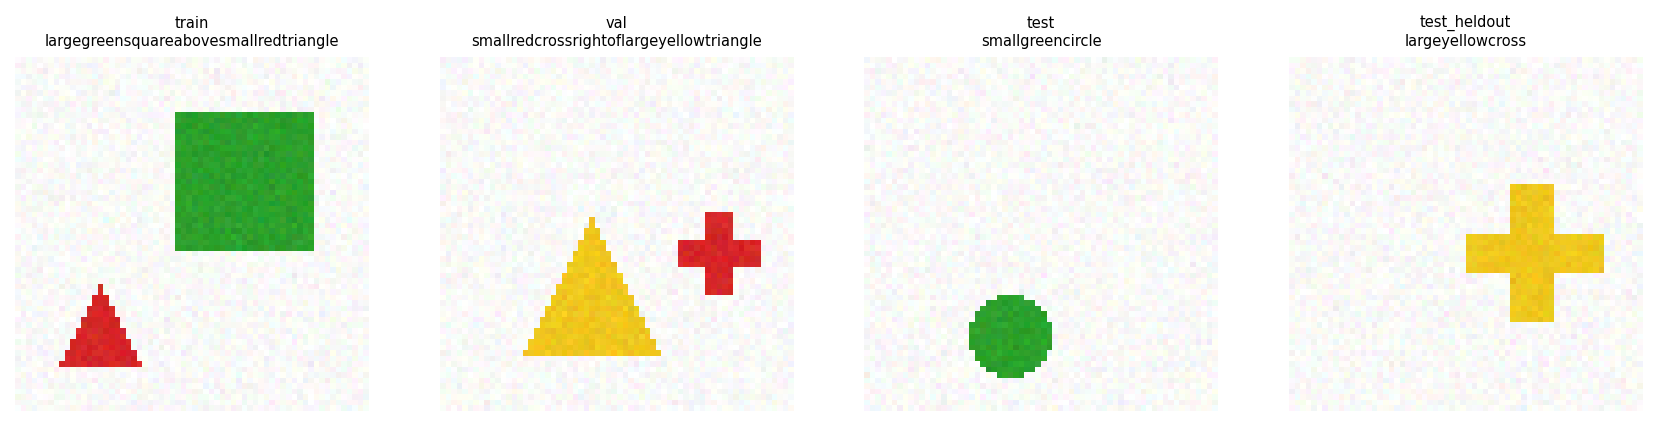

In [ ]:
run("python scripts/inspect_data.py")
from IPython.display import Image, display
display(Image("results/data_samples.png"))

## STEP 5 - tests (attention equivalence, shapes, masks, no future leak, parser). **Fix errors here before going on.**

In [ ]:
run("python -m pytest tests/test_attention.py tests/test_shapes.py tests/test_parser.py -q")
run("python scripts/shapes_demo.py")
commit("Tests pass; shapes printout")

$ python -m pytest tests/test_attention.py tests/test_shapes.py tests/test_parser.py -q
...........                                                              [100%]
11 passed in 1.27s
$ python scripts/shapes_demo.py
word      : largegreensquareabovesmallredtriangle
ids       : [11, 0, 17, 6, 4, 6, 17, 4, 4, 13, 18, 16, 20, 0, 17, 4, 0, 1, 14, 21, 4, 18, 12, 0, 11, 11, 17, 4, 3, 19, 17, 8, 0, 13, 6, 11, 4, 26, 0, 0, 0, 0] -> decoded: largegreensquareabovesmallredtriangle
params    : 2,077,467
images    : (4, 3, 64, 64) torch.uint8 -> preprocessed (4, 3, 64, 64) torch.float32
CNN       : (4, 128, 8, 8)  (B, C, H', W')
flatten   : (4, 64, 128)  (B, H'*W', C)
adapter   : (4, 64, 192)  (B, V, d_model)  visual tokens
letters   : (4, 41, 192)  (B, L, d_model)
sequence  : (4, 105, 192)  (B, V+L, d_model)
decoder   : (4, 105, 192)  (B, V+L, d_model)
logits    : (4, 42, 27)  (B, L+1, 27)  == targets (4, 42)


## STEP 6 - E0: overfit one batch (loss curve must go to ~0)

$ python -u -m src.train --config configs/baseline.yaml --out_dir experiments/E0_overfit --overfit_one_batch
E0 step    0 loss 3.39082
E0 step   50 loss 0.08344
E0 step  100 loss 0.00172
E0 step  150 loss 0.00084
E0 step  200 loss 0.00056
E0 step  250 loss 0.00041
E0 step  300 loss 0.00032
E0 step  350 loss 0.00026
E0 step  399 loss 0.00022
E0 final loss 0.00022 | greedy exact match on the SAME batch: 1.000


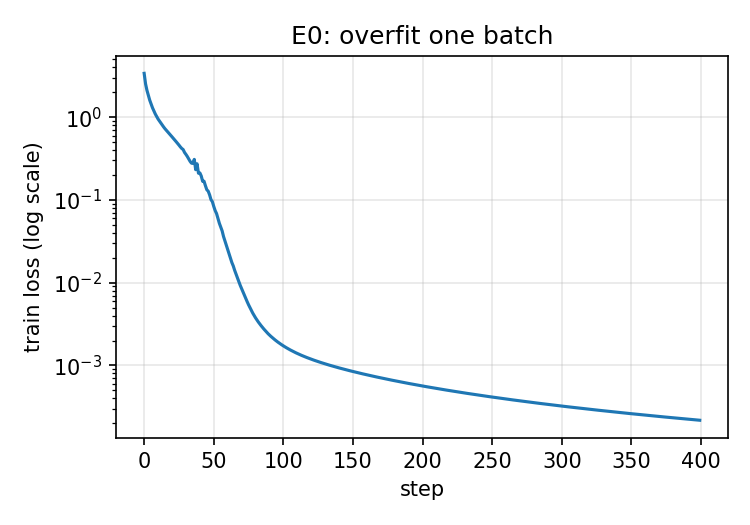

In [ ]:
run("python -u -m src.train --config configs/baseline.yaml --out_dir experiments/E0_overfit --overfit_one_batch")
from IPython.display import Image, display
display(Image("experiments/E0_overfit/e0_loss.png"))
commit("E0: overfit one batch")

## STEP 7 - main model, 3 seeds
Each run trains 20 epochs (set in `configs/baseline.yaml`), saves `last.pt` every epoch (resumable with `--resume`),
then evaluates the best checkpoint on `test` and `test_heldout`. Look at `epoch_time_s` after the first epoch to estimate the total.
If the session dies: run STEP 0, `restore()`, and re-run this cell (finished seeds are re-evaluated quickly; unfinished ones resume).

In [ ]:
SEEDS = [0, 1, 2]
for s in SEEDS:
    run(f"python -u -m src.train --config configs/baseline.yaml --seed {s} --out_dir experiments/main_baseline/seed{s} --resume")
    commit(f"Main model seed {s}: logs and test results")
    try: backup()
    except NameError: pass

$ python -u -m src.train --config configs/baseline.yaml --seed 0 --out_dir experiments/main_baseline/seed0 --resume
device=cuda params=2,077,467 seed=0 blind=none visual_attention=bidirectional
epoch=1 | train_loss=1.1206 | val_loss=0.1707 | lr=0.0008 | epoch_time_s=18.6226
epoch=2 | train_loss=0.0786 | val_loss=0.0544 | lr=0.0010 | epoch_time_s=18.3549
epoch=3 | train_loss=0.0387 | val_loss=0.0448 | lr=0.0010 | epoch_time_s=19.0683
epoch=4 | train_loss=0.0283 | val_loss=0.0363 | lr=0.0010 | epoch_time_s=20.1928
epoch=5 | train_loss=0.0242 | val_loss=0.0217 | lr=0.0009 | val_exact=0.7025 | val_letter_acc=0.6891 | epoch_time_s=45.0147
epoch=6 | train_loss=0.0217 | val_loss=0.0799 | lr=0.0009 | epoch_time_s=19.7473
epoch=7 | train_loss=0.0197 | val_loss=0.0261 | lr=0.0008 | epoch_time_s=20.2430
epoch=8 | train_loss=0.0188 | val_loss=0.0197 | lr=0.0007 | epoch_time_s=20.5495
epoch=9 | train_loss=0.0180 | val_loss=0.0209 | lr=0.0007 | epoch_time_s=20.2750
epoch=10 | train_loss=0.0168 | val

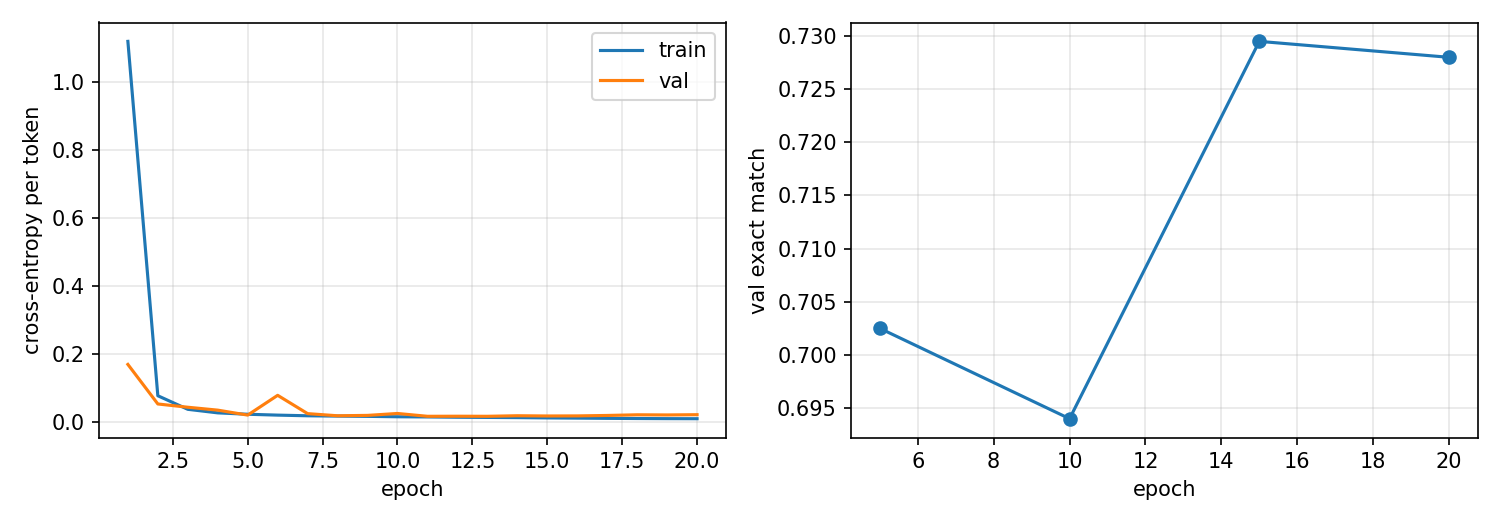

$ python -m src.generate --ckpt experiments/main_baseline/seed0/best.pt --split test --n 8
OK  ref=smallgreencircle
    pred=smallgreencircle
OK  ref=largeredtriangle
    pred=largeredtriangle
OK  ref=largebluecross
    pred=largebluecross
OK  ref=largebluecross
    pred=largebluecross
OK  ref=largebluetriangle
    pred=largebluetriangle
XX  ref=largegreensquarebelowsmallyellowcircle
    pred=smallyellowcircleabovelargegreensquare
OK  ref=smallredsquarebelowsmallgreencross
    pred=smallredsquarebelowsmallgreencross
XX  ref=smallredcrossleftoflargeredtriangle
    pred=largeredtrianglerightofsmallredcross


In [ ]:
from IPython.display import Image, display
display(Image("experiments/main_baseline/seed0/curves.png"))
run("python -m src.generate --ckpt experiments/main_baseline/seed0/best.pt --split test --n 8")

## STEP 8 - E1 blind baseline
**Before running:** open `experiments/E1_blind/notes.md`, rewrite the hypothesis in your own words, then run the next cell
(it commits the notes first, so the commit timestamp proves the hypothesis came before the result).

In [ ]:
commit("E1: hypothesis written before running")
SEEDS_BLIND = [0]          # use [0, 1, 2] if you have time
for s in SEEDS_BLIND:
    run(f"python -u -m src.train --config configs/blind.yaml --seed {s} --out_dir experiments/E1_blind/seed{s} --resume")
    commit(f"E1 blind seed {s}: results")
    try: backup()
    except NameError: pass

$ python -u -m src.train --config configs/blind.yaml --seed 0 --out_dir experiments/E1_blind/seed0 --resume
device=cuda params=2,077,467 seed=0 blind=zeros visual_attention=bidirectional
epoch=1 | train_loss=1.1863 | val_loss=0.4090 | lr=0.0008 | epoch_time_s=20.4963
epoch=2 | train_loss=0.2477 | val_loss=0.3251 | lr=0.0010 | epoch_time_s=21.7318
epoch=3 | train_loss=0.2360 | val_loss=0.3261 | lr=0.0010 | epoch_time_s=19.5694
epoch=4 | train_loss=0.2343 | val_loss=0.3231 | lr=0.0010 | epoch_time_s=18.8470
epoch=5 | train_loss=0.2336 | val_loss=0.4313 | lr=0.0009 | val_exact=0.0000 | val_letter_acc=0.0900 | epoch_time_s=28.1840
epoch=6 | train_loss=0.2330 | val_loss=0.3217 | lr=0.0009 | epoch_time_s=19.9690
epoch=7 | train_loss=0.2324 | val_loss=0.3200 | lr=0.0008 | epoch_time_s=20.0266
epoch=8 | train_loss=0.2320 | val_loss=0.3299 | lr=0.0007 | epoch_time_s=19.5085
epoch=9 | train_loss=0.2314 | val_loss=0.3163 | lr=0.0007 | epoch_time_s=19.3795
epoch=10 | train_loss=0.2312 | val_loss=0

## STEP 9 - E3: causal vs bidirectional attention among visual tokens (3 seeds)
**Before running:** edit the hypothesis in `experiments/E3_visual_mask/notes.md` in your own words.

In [ ]:
commit("E3: hypothesis written before running")
for s in [0, 1, 2]:
    run(f"python -u -m src.train --config configs/e3_causal_visual.yaml --seed {s} --out_dir experiments/E3_visual_mask/seed{s} --resume")
    commit(f"E3 causal seed {s}: results")
    try: backup()
    except NameError: pass

$ python -u -m src.train --config configs/e3_causal_visual.yaml --seed 0 --out_dir experiments/E3_visual_mask/seed0 --resume
device=cuda params=2,077,467 seed=0 blind=none visual_attention=causal
epoch=1 | train_loss=1.1246 | val_loss=0.1782 | lr=0.0008 | epoch_time_s=21.1006
epoch=2 | train_loss=0.0802 | val_loss=0.0403 | lr=0.0010 | epoch_time_s=22.3762
epoch=3 | train_loss=0.0384 | val_loss=0.0317 | lr=0.0010 | epoch_time_s=19.9214
epoch=4 | train_loss=0.0283 | val_loss=0.0274 | lr=0.0010 | epoch_time_s=19.2120
epoch=5 | train_loss=0.0251 | val_loss=0.0218 | lr=0.0009 | val_exact=0.7060 | val_letter_acc=0.6923 | epoch_time_s=45.7103
epoch=6 | train_loss=0.0215 | val_loss=0.0203 | lr=0.0009 | epoch_time_s=20.1703
epoch=7 | train_loss=0.0198 | val_loss=0.0196 | lr=0.0008 | epoch_time_s=20.3869
epoch=8 | train_loss=0.0186 | val_loss=0.0193 | lr=0.0007 | epoch_time_s=20.0218
epoch=9 | train_loss=0.0177 | val_loss=0.0210 | lr=0.0007 | epoch_time_s=19.8930
epoch=10 | train_loss=0.0170 | v

## STEP 10 - S1 throughput (CPU and GPU), profiler, memory, attention benchmark

$ python -u benchmarks/S1_throughput/run_s1.py --config configs/baseline.yaml
cpu  bs=   1  first_iter=0.155s  images/s mean=15.7  min=14.1 max=16.7
cpu  bs=  16  first_iter=0.661s  images/s mean=21.0  min=14.1 max=28.9
cpu  bs=  64  first_iter=3.458s  images/s mean=27.2  min=24.8 max=28.9
cpu  bs= 256  first_iter=11.697s  images/s mean=24.4  min=24.2 max=24.5
cuda bs=   1  first_iter=0.467s  images/s mean=66.9  min=64.8 max=69.9
cuda bs=  16  first_iter=0.061s  images/s mean=704.6  min=651.3 max=752.2
cuda bs=  64  first_iter=0.064s  images/s mean=1183.6  min=1178.5 max=1187.4
cuda bs= 256  first_iter=0.247s  images/s mean=1182.3  min=1140.2 max=1218.3


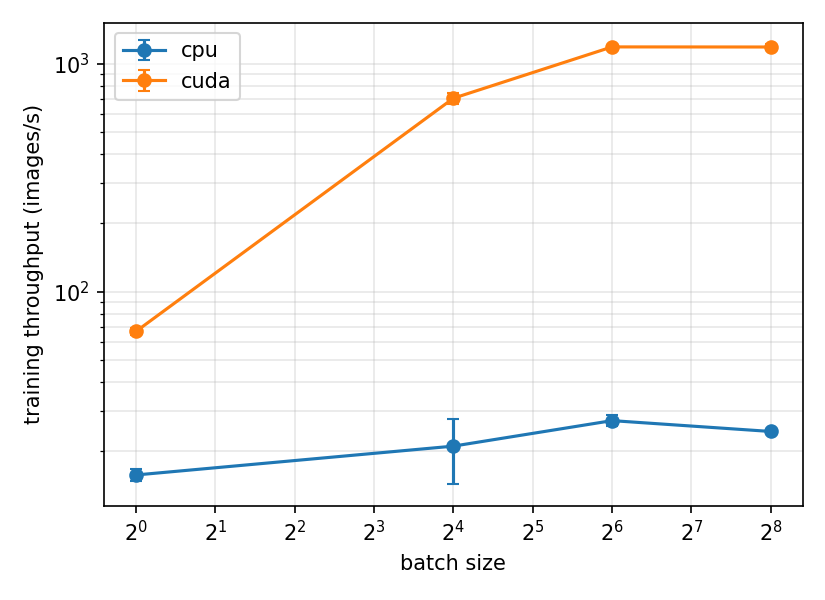

In [ ]:
run("python -u benchmarks/S1_throughput/run_s1.py --config configs/baseline.yaml")
from IPython.display import Image, display
display(Image("benchmarks/S1_throughput/s1_throughput.png"))
commit("S1 throughput benchmark: raw CSV, plot, hardware")

In [ ]:
run("python -u benchmarks/profile_step.py --config configs/baseline.yaml --batch_size 64")
commit("Step breakdown + profiler table")

$ python -u benchmarks/profile_step.py --config configs/baseline.yaml --batch_size 64
device=cuda batch_size=64 num_workers=0 steps=30
data_loading      1.74 ms  (  2.9%)
forward          20.13 ms  ( 33.7%)
backward         35.86 ms  ( 60.0%)
optimizer         2.03 ms  (  3.4%)
total            59.75 ms/step  -> 1071.1 images/s
/usr/local/lib/python3.13/dist-packages/torch/profiler/profiler.py:224: UserWarning: Warning: Profiler clears events at the end of each cycle.Only events from the current cycle will be reported.To keep events across cycles, set acc_events=True.
  _warn_once(
-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                                   Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg     Self CUDA   Self CUDA %    CUDA total  CUDA time avg    # of Calls  
--------------

In [ ]:
run("python -u benchmarks/memory.py --config configs/baseline.yaml")
commit("Memory estimate vs measurement")

$ python -u benchmarks/memory.py --config configs/baseline.yaml
ESTIMATES (computed before measuring):
  batch B=   8 L=45  static=   31.7 MB  activations=    88.1 MB  total=   119.8 MB
  batch B=  16 L=45  static=   31.7 MB  activations=   176.1 MB  total=   207.8 MB
  batch B=  32 L=45  static=   31.7 MB  activations=   352.2 MB  total=   383.9 MB
  batch B=  64 L=45  static=   31.7 MB  activations=   704.4 MB  total=   736.1 MB
  batch B= 128 L=45  static=   31.7 MB  activations=  1408.9 MB  total=  1440.6 MB
  batch B= 256 L=45  static=   31.7 MB  activations=  2817.8 MB  total=  2849.5 MB
  seq   B=  64 L=10  static=   31.7 MB  activations=   496.5 MB  total=   528.2 MB
  seq   B=  64 L=20  static=   31.7 MB  activations=   552.6 MB  total=   584.3 MB
  seq   B=  64 L=30  static=   31.7 MB  activations=   611.4 MB  total=   643.1 MB
  seq   B=  64 L=45  static=   31.7 MB  activations=   704.4 MB  total=   736.1 MB
{'sweep': 'batch', 'batch_size': 8, 'letters': 45, 'seq_len': 109, 

$ python -u benchmarks/attn_bench.py
{'T': 64, 'impl': 'hand', 'mode': 'fwd', 'ms_mean': 0.2748333811759949, 'ms_std': 0.04019458219408989, 'peak_extra_MB': 3.75, 'scores_matrix_MB': 1.5, 'max_abs_diff_vs_other': 7.152557373046875e-07}
{'T': 64, 'impl': 'hand', 'mode': 'fwd+bwd', 'ms_mean': 1.2082122564315796, 'ms_std': 0.0765225812792778, 'peak_extra_MB': 5.2548828125, 'scores_matrix_MB': 1.5, 'max_abs_diff_vs_other': 7.152557373046875e-07}
{'T': 64, 'impl': 'sdpa', 'mode': 'fwd', 'ms_mean': 0.21992798149585724, 'ms_std': 0.04735889285802841, 'peak_extra_MB': 0.765625, 'scores_matrix_MB': 1.5, 'max_abs_diff_vs_other': 7.152557373046875e-07}
{'T': 64, 'impl': 'sdpa', 'mode': 'fwd+bwd', 'ms_mean': 1.0150090456008911, 'ms_std': 0.659812867641449, 'peak_extra_MB': 3.06494140625, 'scores_matrix_MB': 1.5, 'max_abs_diff_vs_other': 7.152557373046875e-07}
{'T': 128, 'impl': 'hand', 'mode': 'fwd', 'ms_mean': 0.4972909092903137, 'ms_std': 0.0162021666765213, 'peak_extra_MB': 13.5, 'scores_matrix

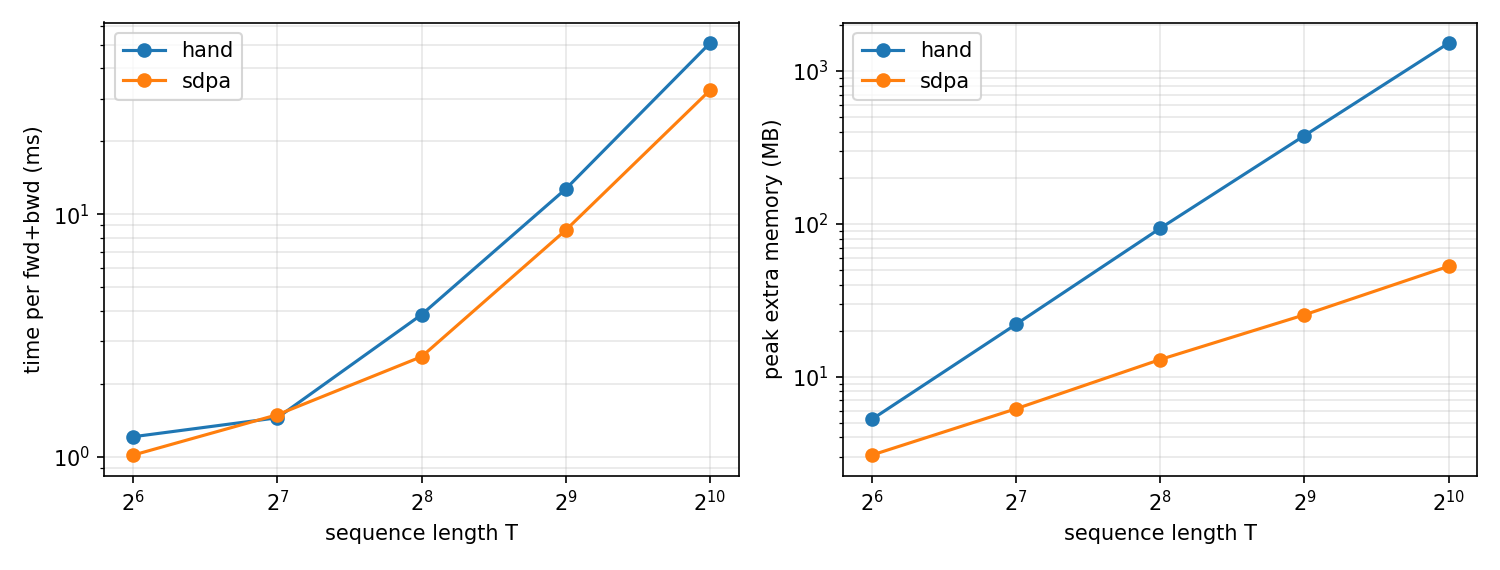

In [ ]:
run("python -u benchmarks/attn_bench.py")
from IPython.display import Image, display
display(Image("benchmarks/attention/attention_bench.png"))
commit("Attention benchmark: handwritten vs SDPA")

## STEP 11 - results table + README

In [ ]:
run("python -m src.aggregate")

$ python -m src.aggregate
| Experiment | Configuration | Metric | Result (mean +- std, n seeds) | Interpretation (1 sentence) |
|---|---|---|---|---|
| Main model | configs/baseline.yaml | Exact match, test | 71.8 +- 0.2% (n=3) | TODO: write 1 sentence |
| Main model | configs/baseline.yaml | Exact match, test_heldout | 37.4 +- 9.0% (n=3) | TODO: write 1 sentence |
| E1 blind (zeros) | configs/blind.yaml | Exact match, test | 0.0% (n=1, no std) | TODO: write 1 sentence |
| E1 blind (zeros) | configs/blind.yaml | Exact match, test_heldout | 0.0% (n=1, no std) | TODO: write 1 sentence |
| E3 causal visual tokens | configs/e3_causal_visual.yaml | Exact match, test | 72.1 +- 0.7% (n=3) | TODO: write 1 sentence |
| E3 causal visual tokens | configs/e3_causal_visual.yaml | Exact match, test_heldout | 33.7 +- 10.9% (n=3) | TODO: write 1 sentence |
| E0 overfit one batch | configs/baseline.yaml | final train loss / exact match on that batch | 0.0002 / 100.0% (n=1) | TODO |
| S1 throughput | ba

In [ ]:
table = open("results/results_table.md").read()
readme = f"""# rls-tiny-vlm: a tiny vision-language model (RLS Entrance Challenge)

## Results

{table}

*The 'Interpretation' column must be written by you from the real numbers. n=1 rows have no std. All numbers: see `results/`, `experiments/`, `benchmarks/`.*

## Reproduce

```bash
pip install -r requirements.txt
bash scripts/run_all.sh        # every command that produced the numbers above
```

Configs: `configs/baseline.yaml` (main), `configs/blind.yaml` (E1: only `blind: zeros` differs), `configs/e3_causal_visual.yaml` (E3: only `visual_attention: causal` differs).
Seeds: 0,1,2 (main, E3), 0 (E1). Data: official `generate_data.py`, seed 42 (hashes in `results/data_sha256.txt`).
Hardware for timings: `benchmarks/*/hardware.txt`.

## Design choices (not specified by the brief)
- CNN: 4 x (Conv3x3-BatchNorm-ReLU) with MaxPool after the first 3 -> 8x8 grid = 64 visual tokens; adapter = Linear(128 -> d_model).
- Decoder: d_model=192, 6 heads, 4 pre-LN blocks, MLP x4, GELU, dropout 0.1, learned positional embeddings over [visual | letters].
- Mask: letters are causal and see all visual tokens; visual tokens never see letters; visual tokens see each other (bidirectional) in the main model.
- Loss: cross-entropy on every letter + `<eos>`; padding positions get label -100. The output at the last visual token predicts the first letter.
- Evaluation: greedy decoding, max 45 letters; robust parser = edit-distance matching on the known grammar (`src/parsing.py`).
- Best checkpoint chosen by validation loss.

## Layout
`src/` model + training + evaluation, `tests/`, `configs/`, `experiments/` (raw logs/results per run), `benchmarks/`, `scripts/`, `report/`.
See `AI_USAGE.md` for how AI tools were used.
"""
open("README.md", "w").write(readme)
print(readme[:1500])
commit("README with results table")

# rls-tiny-vlm: a tiny vision-language model (RLS Entrance Challenge)

## Results

| Experiment | Configuration | Metric | Result (mean +- std, n seeds) | Interpretation (1 sentence) |
|---|---|---|---|---|
| Main model | configs/baseline.yaml | Exact match, test | 71.8 +- 0.2% (n=3) | TODO: write 1 sentence |
| Main model | configs/baseline.yaml | Exact match, test_heldout | 37.4 +- 9.0% (n=3) | TODO: write 1 sentence |
| E1 blind (zeros) | configs/blind.yaml | Exact match, test | 0.0% (n=1, no std) | TODO: write 1 sentence |
| E1 blind (zeros) | configs/blind.yaml | Exact match, test_heldout | 0.0% (n=1, no std) | TODO: write 1 sentence |
| E3 causal visual tokens | configs/e3_causal_visual.yaml | Exact match, test | 72.1 +- 0.7% (n=3) | TODO: write 1 sentence |
| E3 causal visual tokens | configs/e3_causal_visual.yaml | Exact match, test_heldout | 33.7 +- 10.9% (n=3) | TODO: write 1 sentence |
| E0 overfit one batch | configs/baseline.yaml | final train loss / exact match on that ba

## STEP 12 - final: push, backup, then write the report from the real numbers
Report (max 4 pages, organized by topic) goes in `report/report.pdf`. Use the table, plots (`curves.png`, `e0_loss.png`, `s1_throughput.png`,
`attention_bench.png`), and `experiments/*/eval_test_heldout.json` for the error analysis. Do not invent numbers.

In [ ]:
try: backup()
except NameError: pass
push()
run("git log --oneline | head -30")
run("git rev-parse HEAD")

backed up to /content/drive/MyDrive/rls-tiny-vlm-backup
GitHub token (hidden): ··········
remote: Repository not found.
fatal: repository 'https://github.com/your-username/rls-tiny-vlm.git/' not found

$ git log --oneline | head -30
73d071f README with results table
cb0a2e9 Attention benchmark: handwritten vs SDPA
80b7b0c Memory estimate vs measurement
1a17889 Step breakdown + profiler table
c481ef1 S1 throughput benchmark: raw CSV, plot, hardware
a516439 E3 causal seed 2: results
d5b2d71 E3 causal seed 1: results
d3c2437 E3 causal seed 0: results
537e8c9 E1 blind seed 0: results
f1fba80 Main model seed 2: logs and test results
f6f9efb Main model seed 1: logs and test results
aa8f63c Main model seed 0: logs and test results
d7dd697 E0: overfit one batch
5e866eb Tests pass; shapes printout
ae8c037 Add tokenizer, data pipeline, model, training, evaluation, tests, benchmarks
c21f9da  tests/ bugs founded and fixed
d7b64f7 some changes
4014e3a  the architecture of the project
468d5cc first 